# Paper figures (`no_comms`): architecture comparison across sizes 6, 12, and 25

This notebook compares `task_routed` and `single_module` architectures only (shared input routing excluded) under the `no_comms` setting across hidden sizes `6`, `12`, and `25`.

It uses the current blueprint-aligned participant-level metrics:
- **Transfer**: `transfer_error_diff = mean(first 6 B winter) - mean(last 6 A1 winter)`
- **Retest interference**: `interference = 1 - A_weight_A2` from von Mises fit CSVs

The flow mirrors the existing `no_comms_architecture_comparison` notebooks, but adds hidden size as an explicit comparison dimension.


In [16]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:
    display = print

SIMILARITY_ORDER = ["same", "near", "far"]
INTERFERENCE_ORDER = ["near", "far"]
SIZE_ORDER = [6, 12, 25]
PAPER_INIT_SCALES = [0.001, 0.01, 0.1, 1.0, 2.0]
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False
TARGET_TWO_MODULE_ARCH = "two_module_rnn"
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]
ROUTING_ORDER = ["task_routed", "shared", "single_module"]
ROUTING_PALETTE = {
    "task_routed": "#4C72B0",
    "shared": "#55A868",
    "single_module": "#C44E52",
}

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.paper_single_baseline import select_single_baseline_df

sim_folder = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = json.loads(config_path.read_text())

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Config:", config_path)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Config: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/experiments.json


In [17]:
# 2) Build a cross-size no_comms inventory across architecture groups

def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def _match_common_filters(c, *, size):
    return (
        c.get("arch") == TARGET_TWO_MODULE_ARCH
        and c.get("dim_hidden") == size
        and c.get("nb_steps", 1) == TARGET_NB_STEPS
        and c.get("common_readout", True) is TARGET_COMMON_READOUT
        and c.get("common_input", False) is TARGET_COMMON_INPUT
    )


def select_two_module_conditions(size: int, input_routing: str) -> pd.DataFrame:
    rows = []
    for c in settings["conditions"]:
        if not _match_common_filters(c, size=size):
            continue
        if c.get("input_routing", "shared") != input_routing:
            continue
        sp_label = sparsity_label_from_condition(c)
        init_scale = init_scale_from_condition(c)
        if sp_label != "no_comms":
            continue
        if init_scale not in PAPER_INIT_SCALES:
            continue
        run_id = build_run_id(c)
        folder_path = sim_folder / run_id
        fit_path = sim_folder / f"{run_id}_vonmises_fits.csv"
        rows.append({
            **c,
            "size": size,
            "routing": input_routing,
            "architecture_group": input_routing,
            "run_id": run_id,
            "folder_path": str(folder_path),
            "path_exists": folder_path.exists(),
            "sparsity_label": "no_comms",
            "init_scale": init_scale,
            "vonmises_path": str(fit_path),
            "vonmises_exists": fit_path.exists(),
            "n_npz": len(sorted(folder_path.glob("sim_*.npz"))) if folder_path.exists() else 0,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["size", "init_scale", "name"]).reset_index(drop=True)


def select_single_module_conditions(size: int) -> pd.DataFrame:
    df = select_single_baseline_df(
        settings,
        sim_folder,
        two_module_dim_hidden=size,
        paper_sparsities=["1.0"],
        paper_init_scales=PAPER_INIT_SCALES,
        sparsity_order=SPARSITY_ORDER,
        build_run_id=build_run_id,
        sparsity_label_from_condition=sparsity_label_from_condition,
        init_scale_from_condition=init_scale_from_condition,
        target_nb_steps=TARGET_NB_STEPS,
        target_common_readout=TARGET_COMMON_READOUT,
        target_common_input=TARGET_COMMON_INPUT,
    )
    if df.empty:
        return df
    df = df.copy()
    df["size"] = size
    df["routing"] = "single_module"
    df["architecture_group"] = "single_module"
    df["sparsity_label"] = "no_comms"
    df["folder_path"] = df["path"]
    df["vonmises_path"] = df["run_id"].map(lambda rid: str(sim_folder / f"{rid}_vonmises_fits.csv"))
    df["vonmises_exists"] = df["vonmises_path"].map(lambda p: Path(p).exists())
    df["n_npz"] = df["folder_path"].map(lambda p: len(sorted(Path(p).glob("sim_*.npz"))) if Path(p).exists() else 0)
    return df.sort_values(["size", "init_scale", "name"]).reset_index(drop=True)


run_parts = []
for size in SIZE_ORDER:
    run_parts.append(select_two_module_conditions(size, "task_routed"))
    run_parts.append(select_single_module_conditions(size))

grid_df = pd.concat([df for df in run_parts if df is not None and not df.empty], ignore_index=True)
grid_df["init_scale"] = grid_df["init_scale"].astype(float)
grid_df["size"] = grid_df["size"].astype(int)

display(
    grid_df[
        [
            "size", "architecture_group", "name", "run_id", "init_scale",
            "path_exists", "vonmises_exists", "n_npz"
        ]
    ].sort_values(["size", "architecture_group", "init_scale", "name"]).reset_index(drop=True)
)


,size,architecture_group,name,run_id,init_scale,path_exists,vonmises_exists,n_npz
0,6,single_module,single_module_rnn_12_nb2_init0.001,single_module_rnn_12_nb2_init0.001_nb2_shared_...,0.001,True,True,305
1,6,single_module,single_module_rnn_12_nb2_init0.01,single_module_rnn_12_nb2_init0.01_nb2_shared_s...,0.010,True,True,305
2,6,single_module,single_module_rnn_12_nb2_init0.1,single_module_rnn_12_nb2_init0.1_nb2_shared_sp...,0.100,True,False,305
3,6,single_module,single_module_rnn_12_nb2,single_module_rnn_12_nb2_nb2_shared_sp1_sep_cr...,1.000,True,True,305
4,6,single_module,single_module_rnn_12_nb2_init2,single_module_rnn_12_nb2_init2_nb2_shared_sp1_...,2.000,True,True,305
5,6,task_routed,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.001,True,False,305
6,6,task_routed,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.001,False,False,0
7,6,task_routed,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.010,True,False,305
8,6,task_routed,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.010,False,False,0
9,6,task_routed,two_module_rnn_6_task_routed_no_comms_nb2_init0.1,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.100,True,False,305


In [18]:
# 3) Build participant-level metric dataframes from raw files

REQUIRED_RAW_KEYS = ["accuracy", "probes", "test_stim", "indexes"]


def load_raw_ann_folder(folder: Path, keys=None):
    keys = list(REQUIRED_RAW_KEYS if keys is None else keys)
    condition_data = {"same": [], "near": [], "far": []}
    if not folder.exists():
        return condition_data
    for npz_path in sorted(folder.glob("sim_*.npz")):
        file_name = npz_path.name
        condition = next((cond for cond in condition_data if cond in file_name), None)
        if condition is None:
            continue
        with np.load(npz_path, allow_pickle=True) as data:
            entry = {"participant": npz_path.stem.replace("sim_", "")}
            for key in keys:
                if key in data:
                    entry[key] = data[key]
        condition_data[condition].append(entry)
    return condition_data


def build_raw_ann_cache(grid: pd.DataFrame, keys=None):
    cache = {}
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading raw no_comms runs"):
        cache[row["run_id"]] = load_raw_ann_folder(Path(row["folder_path"]), keys=keys)
    return cache


def compute_transfer_df_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing transfer"):
        ann_data = raw_cache.get(row["run_id"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                if "accuracy" not in entry:
                    continue
                acc = np.asarray(entry["accuracy"])
                if acc.ndim < 2 or acc.shape[0] < 2:
                    continue
                a1_winter = acc[0, 1::2].astype(float)
                b_winter = acc[1, 1::2].astype(float)
                if len(a1_winter) < 6 or len(b_winter) < 6:
                    continue
                rows.append({
                    "size": int(row["size"]),
                    "architecture_group": row["architecture_group"],
                    "init_scale": float(row["init_scale"]),
                    "run_id": row["run_id"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "transfer_error_diff": float(np.nanmean(b_winter[:6]) - np.nanmean(a1_winter[-6:])),
                })
    return pd.DataFrame(rows)


def compute_generalisation_df_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing generalisation"):
        ann_data = raw_cache.get(row["run_id"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                required = {"accuracy", "probes", "test_stim", "indexes"}
                if not required.issubset(entry):
                    rows.append({
                        "size": int(row["size"]),
                        "architecture_group": row["architecture_group"],
                        "init_scale": float(row["init_scale"]),
                        "run_id": row["run_id"],
                        "participant": entry["participant"],
                        "condition": condition,
                        "generalisation_paper_faithful": np.nan,
                        "generalisation_holton_ann_style": np.nan,
                        "n_generalisation_trials_paper": 0,
                        "n_generalisation_trials_holton": 0,
                        "missing_required_keys": True,
                    })
                    continue
                acc = np.asarray(entry["accuracy"])
                probes = np.asarray(entry["probes"])
                test_stim = np.asarray(entry["test_stim"])
                indexes = np.asarray(entry["indexes"])
                if acc.ndim < 2:
                    continue
                a1_acc = acc[0].astype(float)
                a1_probe = probes[0].astype(float)
                a1_test = test_stim[0].astype(float)
                a1_idx = indexes[0].astype(float)
                valid = np.isfinite(a1_acc) & np.isfinite(a1_probe) & np.isfinite(a1_test) & np.isfinite(a1_idx)
                winter_mask = a1_probe == 1
                test_mask = a1_test == 1
                holton_mask = valid & winter_mask & test_mask
                trial_pos = np.arange(len(a1_acc), dtype=int)
                block_in_schedule = (trial_pos // 12) % 10
                late_mask = block_in_schedule >= 5
                paper_mask = holton_mask & late_mask
                rows.append({
                    "size": int(row["size"]),
                    "architecture_group": row["architecture_group"],
                    "init_scale": float(row["init_scale"]),
                    "run_id": row["run_id"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "generalisation_paper_faithful": float(np.nanmean(a1_acc[paper_mask])) if np.any(paper_mask) else np.nan,
                    "generalisation_holton_ann_style": float(np.nanmean(a1_acc[holton_mask])) if np.any(holton_mask) else np.nan,
                    "n_generalisation_trials_paper": int(np.sum(paper_mask)),
                    "n_generalisation_trials_holton": int(np.sum(holton_mask)),
                    "missing_required_keys": False,
                })
    return pd.DataFrame(rows)


def compute_secondary_ann_metrics_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing secondary ANN metrics"):
        ann_data = raw_cache.get(row["run_id"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                if "accuracy" not in entry:
                    continue
                acc = np.asarray(entry["accuracy"])
                if acc.ndim < 2 or acc.shape[0] < 3:
                    continue
                a1_winter = acc[0, 1::2].astype(float)
                b_winter = acc[1, 1::2].astype(float)
                a2_winter = acc[2, 1::2].astype(float)
                a1_summer = acc[0, 0::2].astype(float)
                if len(a1_winter) < 6 or len(b_winter) < 6 or len(a2_winter) == 0 or len(a1_summer) == 0:
                    continue
                final_a1 = float(np.nanmean(a1_winter[-6:]))
                initial_b = float(np.nanmean(b_winter[:6]))
                a2_mean = float(np.nanmean(a2_winter))
                rows.append({
                    "size": int(row["size"]),
                    "architecture_group": row["architecture_group"],
                    "init_scale": float(row["init_scale"]),
                    "run_id": row["run_id"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "summer_accuracy_taskA_scoped": float(np.nanmean(a1_summer)),
                    "retest_error_diff": a2_mean - final_a1,
                    "transfer_error_diff_recomputed": initial_b - final_a1,
                })
    return pd.DataFrame(rows)


def load_interference_df(grid: pd.DataFrame):
    rows = []
    valid_grid = grid[grid["vonmises_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading von Mises fits"):
        fit_df = pd.read_csv(row["vonmises_path"]).copy()
        required = {"participant", "condition", "A_weight_A2"}
        if not required.issubset(fit_df.columns):
            continue
        fit_df = fit_df[fit_df["condition"].isin(INTERFERENCE_ORDER)].copy()
        if fit_df.empty:
            continue
        fit_df["size"] = int(row["size"])
        fit_df["architecture_group"] = row["architecture_group"]
        fit_df["init_scale"] = float(row["init_scale"])
        fit_df["run_id"] = row["run_id"]
        fit_df["interference"] = 1.0 - fit_df["A_weight_A2"].astype(float)
        rows.append(fit_df[["participant", "condition", "size", "architecture_group", "init_scale", "run_id", "A_weight_A2", "interference"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def load_principal_angles_df(grid: pd.DataFrame):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading principal angles"):
        ann_data = ann.load_ann_data(Path(row["folder_path"]))
        angles_df = ann.get_principal_angles(ann_data)
        if angles_df is None or angles_df.empty:
            continue
        angles_df = angles_df.copy()
        angles_df["size"] = int(row["size"])
        angles_df["architecture_group"] = row["architecture_group"]
        angles_df["init_scale"] = float(row["init_scale"])
        angles_df["run_id"] = row["run_id"]
        rows.append(angles_df[["condition", "principal_angle_between", "size", "architecture_group", "init_scale", "run_id"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def load_representation_df(grid: pd.DataFrame):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    phase_order = ["post_A", "post_B", "post_A2"]
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading representation metrics"):
        ann_data = ann.load_ann_data(Path(row["folder_path"]))
        for condition, entries in ann_data.items():
            if condition not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                participant = str(entry.get("participant"))
                for phase_idx, phase_name in enumerate(phase_order):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for pathway in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=pathway)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(
                            hids, variance_thresholds=(0.95, 0.99), top_k=2
                        )
                        rep_row = {
                            "participant": participant,
                            "condition": condition,
                            "phase": phase_name,
                            "pathway": pathway,
                            "size": int(row["size"]),
                            "architecture_group": row["architecture_group"],
                            "init_scale": float(row["init_scale"]),
                            "run_id": row["run_id"],
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            rep_row[f"n_pcs_{int(thr * 100)}"] = int(n)
                        rows.append(rep_row)
    return pd.DataFrame(rows)


raw_ann_cache = build_raw_ann_cache(grid_df, keys=REQUIRED_RAW_KEYS)
transfer_df = compute_transfer_df_from_cache(grid_df, raw_ann_cache)
generalisation_df = compute_generalisation_df_from_cache(grid_df, raw_ann_cache)
secondary_ann_df = compute_secondary_ann_metrics_from_cache(grid_df, raw_ann_cache)
interference_df = load_interference_df(grid_df)
angles_df = load_principal_angles_df(grid_df)
representation_df = load_representation_df(grid_df)

print("transfer_df:", transfer_df.shape)
print("generalisation_df:", generalisation_df.shape)
print("secondary_ann_df:", secondary_ann_df.shape)
print("interference_df:", interference_df.shape)
print("angles_df:", angles_df.shape)
print("representation_df:", representation_df.shape)


Loading representation metrics: 100%|██████████| 34/34 [01:05<00:00,  1.94s/it]

transfer_df: (10284, 7)
generalisation_df: (10284, 11)
secondary_ann_df: (10284, 9)
interference_df: (3434, 8)
angles_df: (10284, 6)
representation_df: (30852, 11)


## Coverage diagnostics

In [19]:
run_coverage = (
    grid_df.groupby(["size", "architecture_group", "init_scale"], observed=True)
    .agg(
        selected_runs=("run_id", "nunique"),
        valid_runs=("path_exists", "sum"),
        vonmises_runs=("vonmises_exists", "sum"),
        total_npz=("n_npz", "sum"),
    )
    .reset_index()
    .sort_values(["size", "architecture_group", "init_scale"])
)
display(run_coverage)

if not transfer_df.empty:
    transfer_counts = (
        transfer_df.groupby(["size", "architecture_group", "init_scale", "condition"], observed=True)
        .agg(n_participants=("participant", "nunique"), mean_transfer=("transfer_error_diff", "mean"))
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition"])
    )
    display(transfer_counts)
else:
    print("Transfer dataframe is empty.")

if not interference_df.empty:
    interference_counts = (
        interference_df.groupby(["size", "architecture_group", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_A_weight_A2=("A_weight_A2", "mean"),
            mean_interference=("interference", "mean"),
        )
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition"])
    )
    display(interference_counts)
else:
    print("Interference dataframe is empty.")

if not angles_df.empty:
    angle_counts = (
        angles_df.groupby(["size", "architecture_group", "init_scale", "condition"], observed=True)
        .agg(
            n_rows=("principal_angle_between", "size"),
            mean_principal_angle=("principal_angle_between", "mean"),
        )
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition"])
    )
    display(angle_counts)
else:
    print("Angles dataframe is empty.")

if not generalisation_df.empty:
    generalisation_counts = (
        generalisation_df.groupby(["size", "architecture_group", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_generalisation_paper=("generalisation_paper_faithful", "mean"),
            mean_generalisation_holton=("generalisation_holton_ann_style", "mean"),
            mean_trials_paper=("n_generalisation_trials_paper", "mean"),
            mean_trials_holton=("n_generalisation_trials_holton", "mean"),
        )
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition"])
    )
    display(generalisation_counts)
else:
    print("Generalisation dataframe is empty.")

if not secondary_ann_df.empty:
    secondary_counts = (
        secondary_ann_df.groupby(["size", "architecture_group", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_summer_taskA=("summer_accuracy_taskA_scoped", "mean"),
            mean_retest_error_diff=("retest_error_diff", "mean"),
        )
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition"])
    )
    display(secondary_counts)
else:
    print("Secondary ANN metrics dataframe is empty.")

if not representation_df.empty and "n_pcs_99" in representation_df.columns:
    rep_counts = (
        representation_df[
            (representation_df["pathway"] == "combined")
            & (representation_df["phase"].isin(["post_A", "post_B"]))
        ]
        .groupby(["size", "architecture_group", "init_scale", "condition", "phase"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_n_pcs_99=("n_pcs_99", "mean"),
        )
        .reset_index()
        .sort_values(["size", "architecture_group", "init_scale", "condition", "phase"])
    )
    display(rep_counts)
else:
    print("Representation dataframe is empty or n_pcs_99 is unavailable.")


,size,architecture_group,init_scale,selected_runs,valid_runs,vonmises_runs,total_npz
0,6,single_module,0.001,1,1,1,305
1,6,single_module,0.010,1,1,1,305
2,6,single_module,0.100,1,1,0,305
3,6,single_module,1.000,1,1,1,305
4,6,single_module,2.000,1,1,1,305
5,6,task_routed,0.001,2,1,0,305
6,6,task_routed,0.010,2,1,0,305
7,6,task_routed,0.100,2,1,0,305
8,6,task_routed,1.000,2,1,0,305
9,6,task_routed,2.000,2,1,0,305


,size,architecture_group,init_scale,condition,n_participants,mean_transfer
0,6,single_module,0.001,far,101,-0.599757
1,6,single_module,0.001,near,101,-0.453808
2,6,single_module,0.001,same,103,-0.438382
3,6,single_module,0.010,far,101,-0.599816
4,6,single_module,0.010,near,101,-0.453702
5,6,single_module,0.010,same,103,-0.438286
6,6,single_module,0.100,far,101,-0.598181
7,6,single_module,0.100,near,101,-0.451618
8,6,single_module,0.100,same,103,-0.442320
9,6,single_module,1.000,far,101,-0.479088


,size,architecture_group,init_scale,condition,n_participants,mean_A_weight_A2,mean_interference
0,6,single_module,0.001,far,101,0.616110,0.383890
1,6,single_module,0.001,near,101,0.000017,0.999983
2,6,single_module,0.010,far,101,0.999675,0.000325
3,6,single_module,0.010,near,101,0.000018,0.999982
4,6,single_module,1.000,far,101,0.950642,0.049358
5,6,single_module,1.000,near,101,0.590164,0.409836
6,6,single_module,2.000,far,101,0.762860,0.237140
7,6,single_module,2.000,near,101,0.642798,0.357202
8,12,single_module,0.001,far,101,0.481173,0.518827
9,12,single_module,0.001,near,101,0.000017,0.999983


,size,architecture_group,init_scale,condition,n_rows,mean_principal_angle
0,6,single_module,0.001,far,101,41.360697
1,6,single_module,0.001,near,101,0.765102
2,6,single_module,0.001,same,103,0.657849
3,6,single_module,0.010,far,101,73.199653
4,6,single_module,0.010,near,101,0.865961
5,6,single_module,0.010,same,103,0.658412
6,6,single_module,0.100,far,101,85.516796
7,6,single_module,0.100,near,101,1.620106
8,6,single_module,0.100,same,103,0.769121
9,6,single_module,1.000,far,101,66.651791


,size,architecture_group,init_scale,condition,n_participants,mean_generalisation_paper,mean_generalisation_holton,mean_trials_paper,mean_trials_holton
0,6,single_module,0.001,far,101,0.759018,0.757003,500.0,1000.0
1,6,single_module,0.001,near,101,0.756512,0.754554,500.0,1000.0
2,6,single_module,0.001,same,103,0.759092,0.757280,500.0,1000.0
3,6,single_module,0.010,far,101,0.826705,0.824737,500.0,1000.0
4,6,single_module,0.010,near,101,0.825300,0.823373,500.0,1000.0
5,6,single_module,0.010,same,103,0.826563,0.824787,500.0,1000.0
6,6,single_module,0.100,far,101,0.892738,0.891099,500.0,1000.0
7,6,single_module,0.100,near,101,0.893295,0.891815,500.0,1000.0
8,6,single_module,0.100,same,103,0.892644,0.891225,500.0,1000.0
9,6,single_module,1.000,far,101,0.708668,0.708183,500.0,1000.0


,size,architecture_group,init_scale,condition,n_participants,mean_summer_taskA,mean_retest_error_diff
0,6,single_module,0.001,far,101,0.884003,-0.444593
1,6,single_module,0.001,near,101,0.885446,-0.122951
2,6,single_module,0.001,same,103,0.883868,-0.010760
3,6,single_module,0.010,far,101,0.919993,-0.084105
4,6,single_module,0.010,near,101,0.921086,-0.122848
5,6,single_module,0.010,same,103,0.920001,-0.010747
6,6,single_module,0.100,far,101,0.956996,-0.028739
7,6,single_module,0.100,near,101,0.957605,-0.120739
8,6,single_module,0.100,same,103,0.957188,-0.010628
9,6,single_module,1.000,far,101,0.990611,-0.137120


,size,architecture_group,init_scale,condition,phase,n_participants,mean_n_pcs_99
0,6,single_module,0.001,far,post_A,101,2.000000
1,6,single_module,0.001,far,post_B,101,3.990099
2,6,single_module,0.001,near,post_A,101,2.000000
3,6,single_module,0.001,near,post_B,101,2.000000
4,6,single_module,0.001,same,post_A,103,2.000000
5,6,single_module,0.001,same,post_B,103,2.000000
6,6,single_module,0.010,far,post_A,101,2.000000
7,6,single_module,0.010,far,post_B,101,4.000000
8,6,single_module,0.010,near,post_A,101,2.000000
9,6,single_module,0.010,near,post_B,101,2.000000


## Quantitative architecture comparison (`no_comms`)

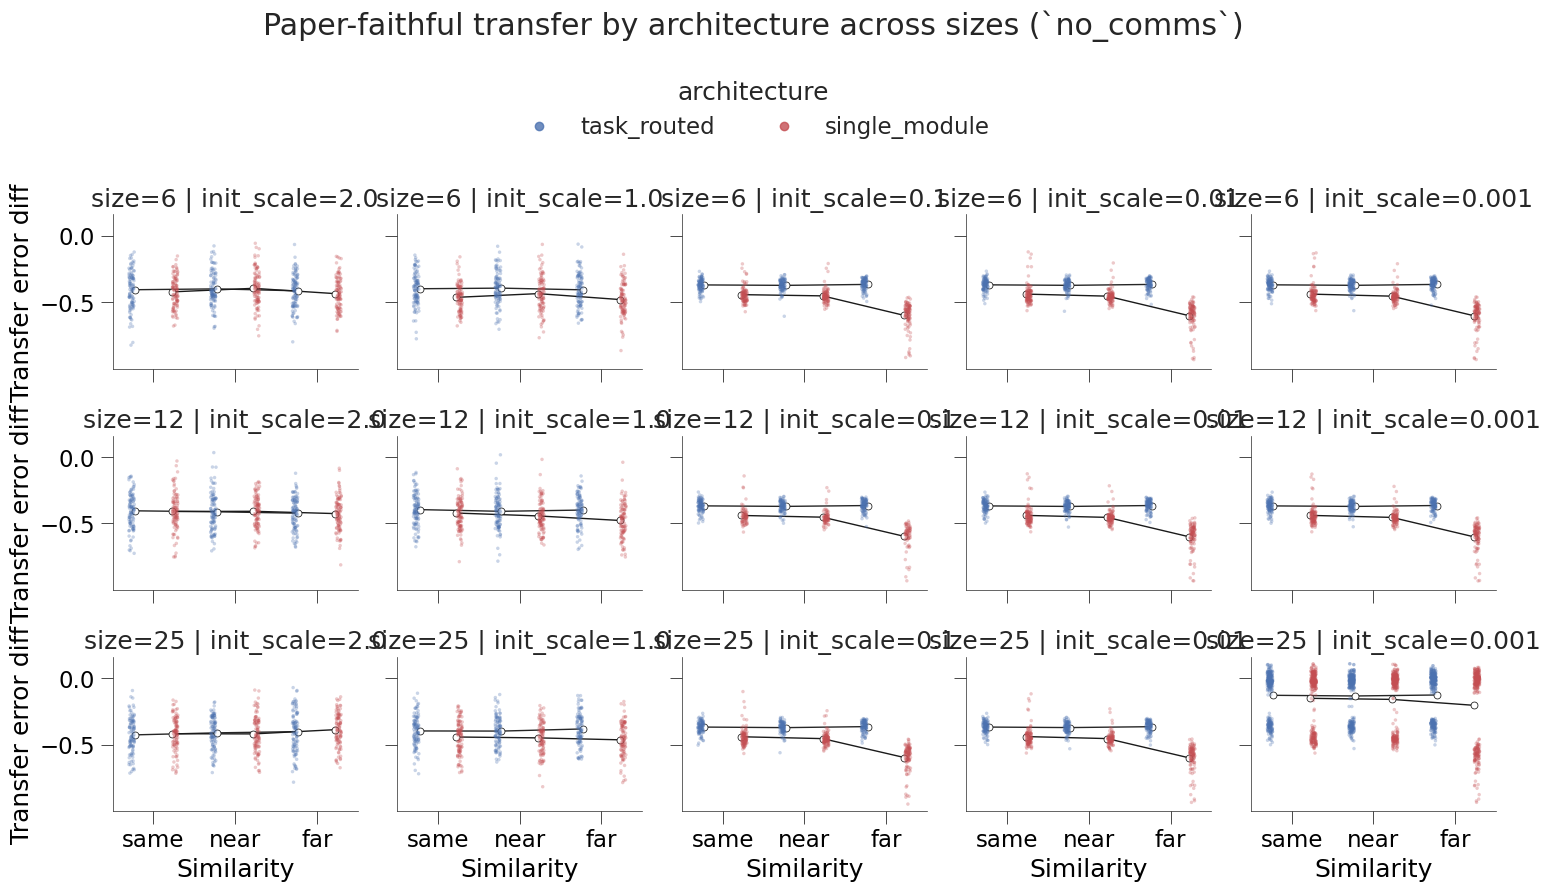

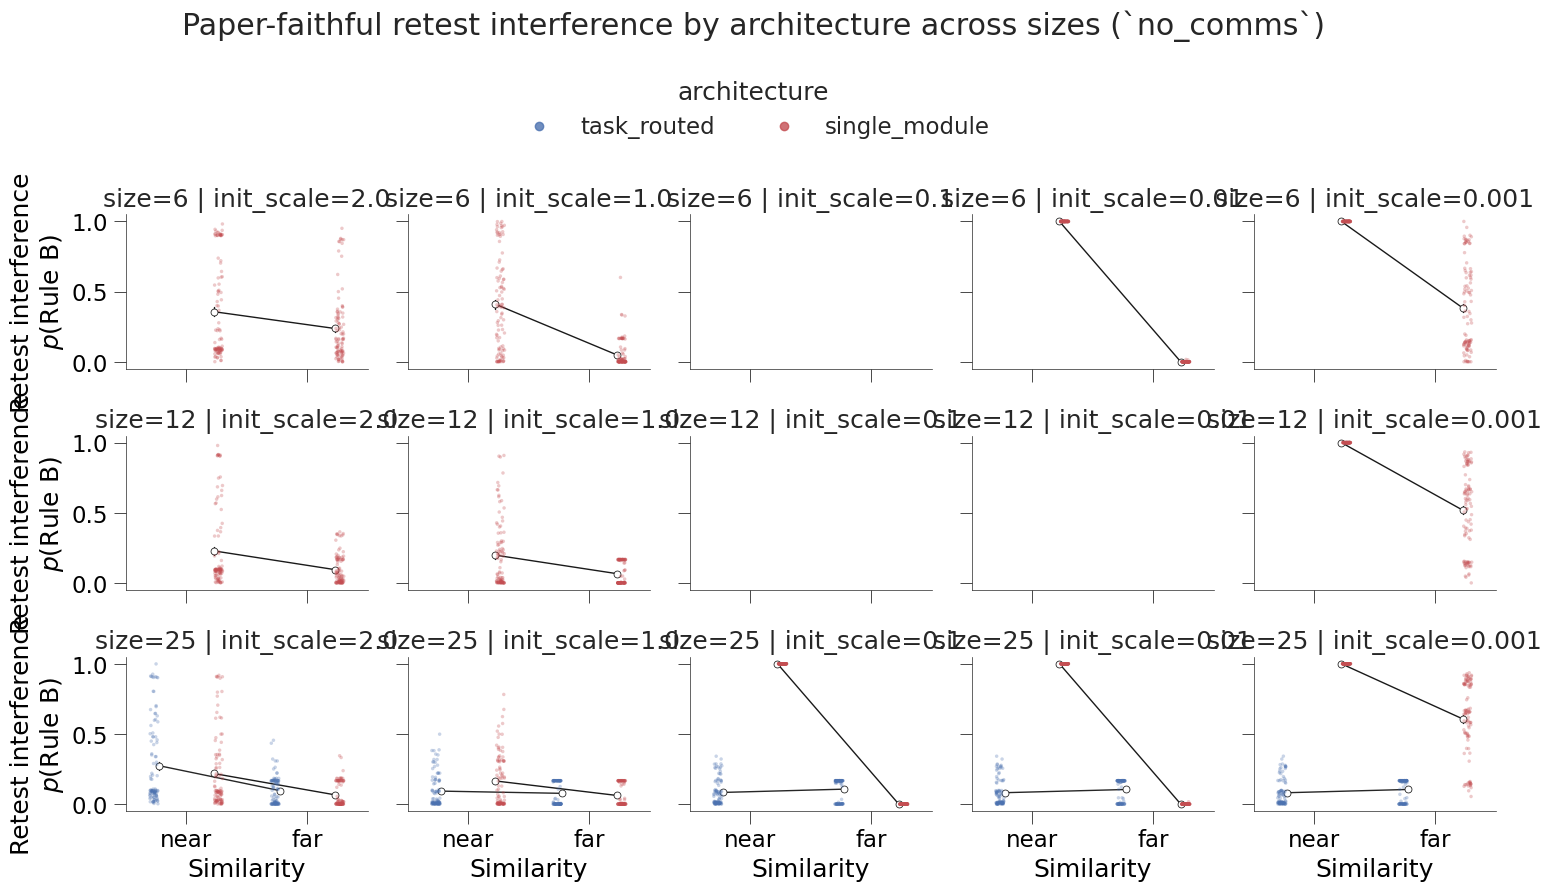

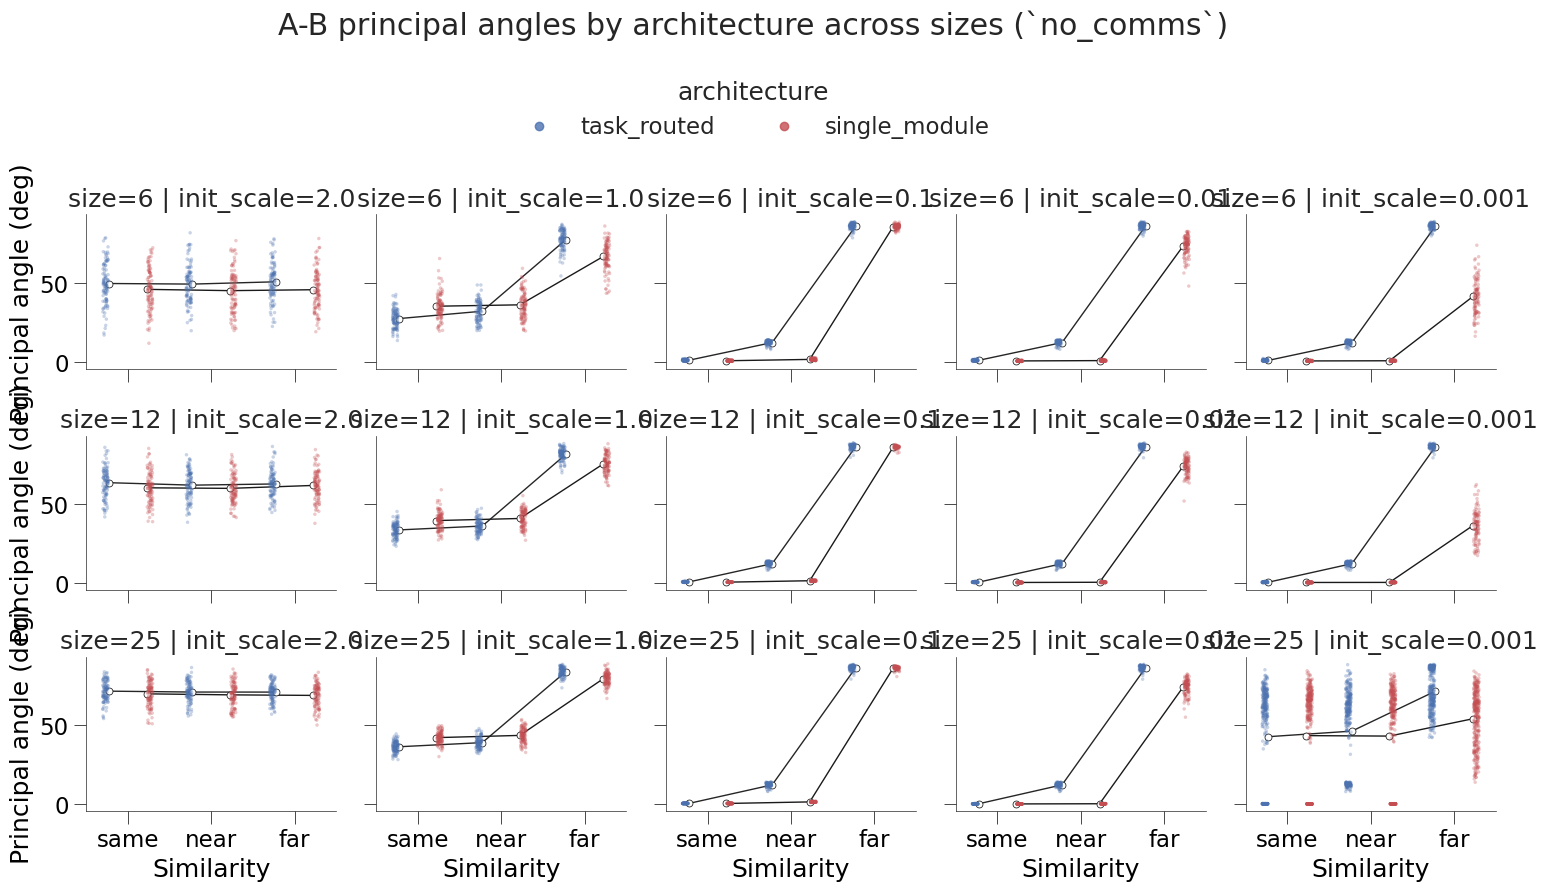

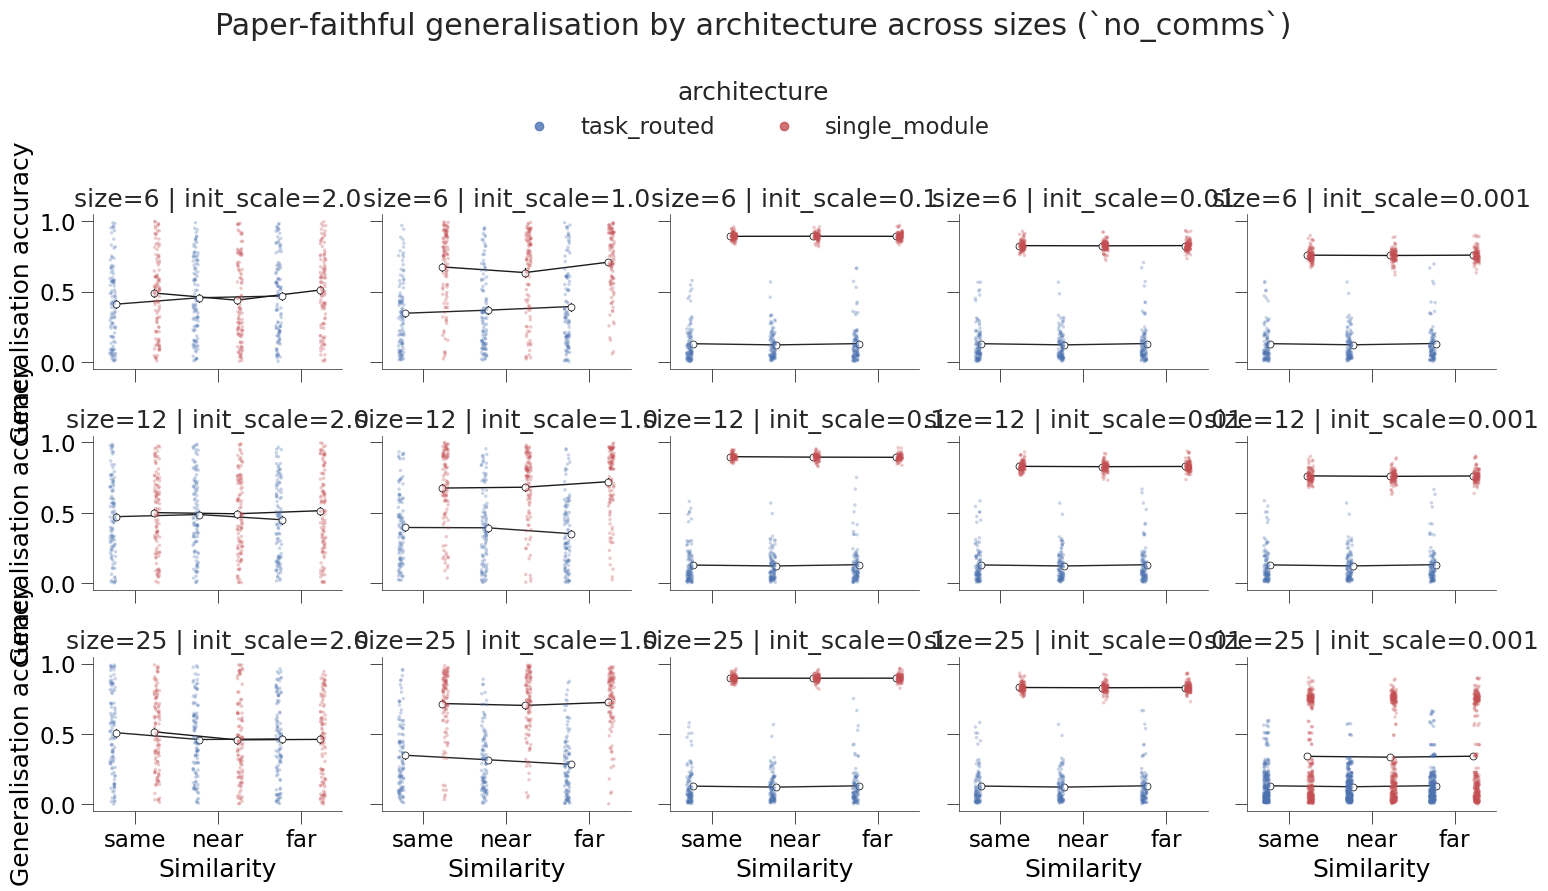

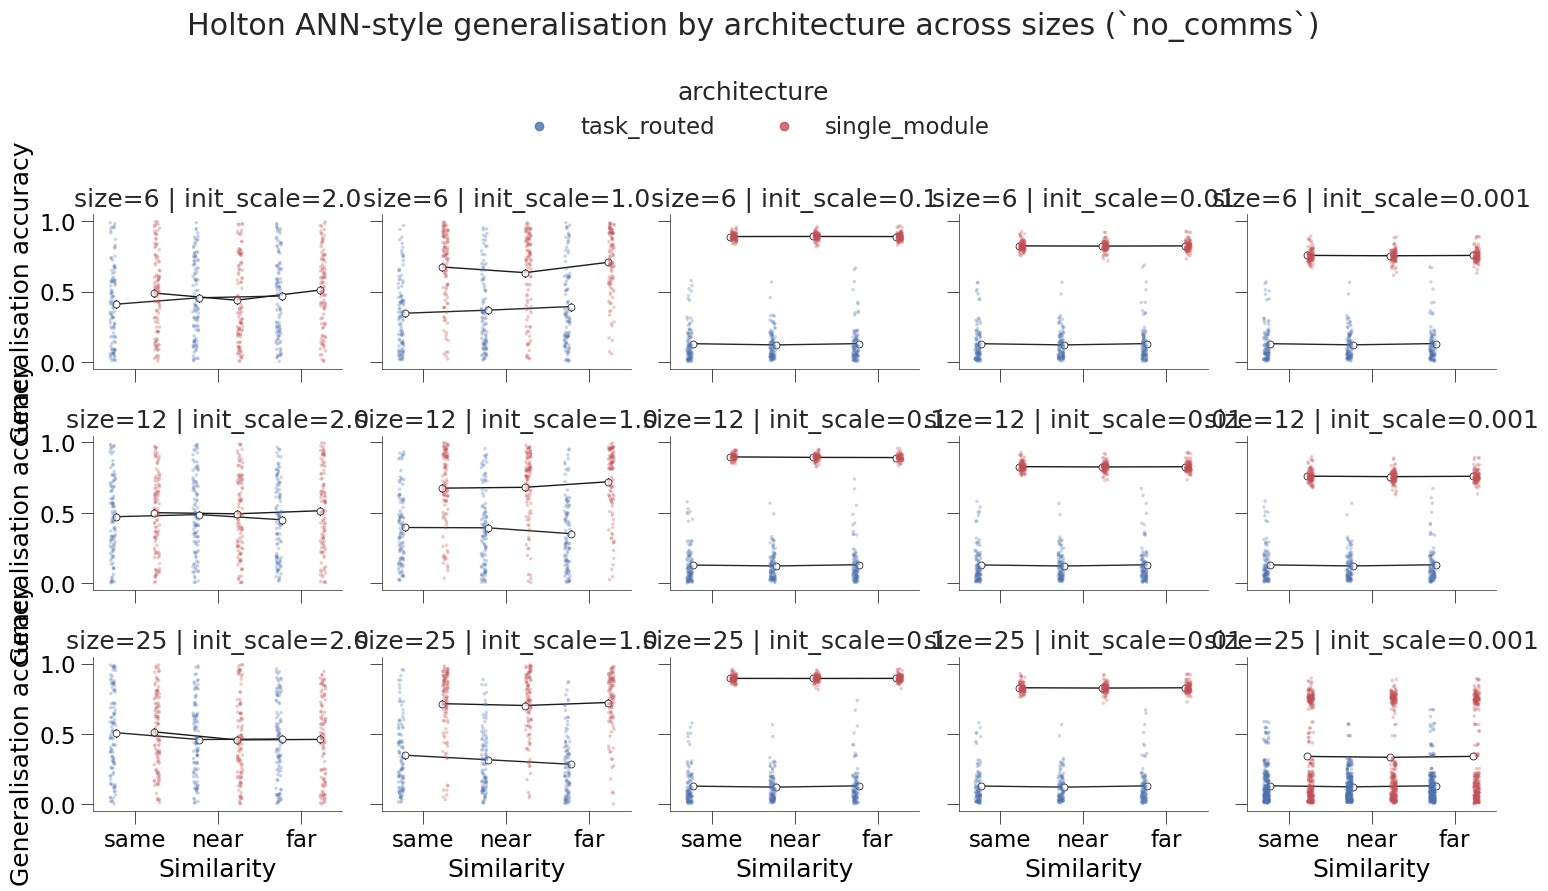

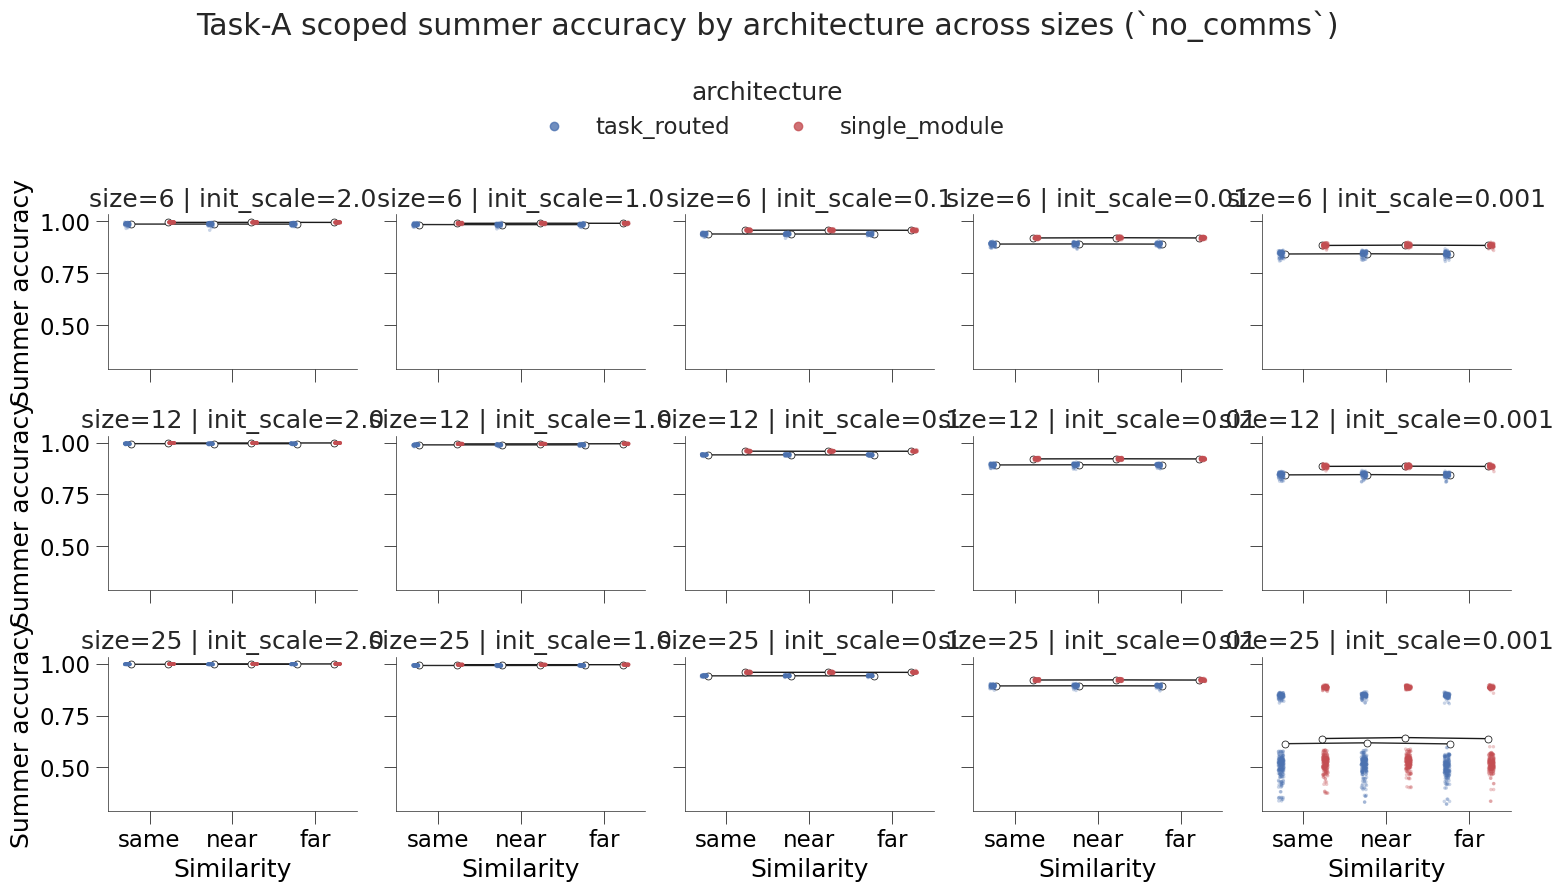

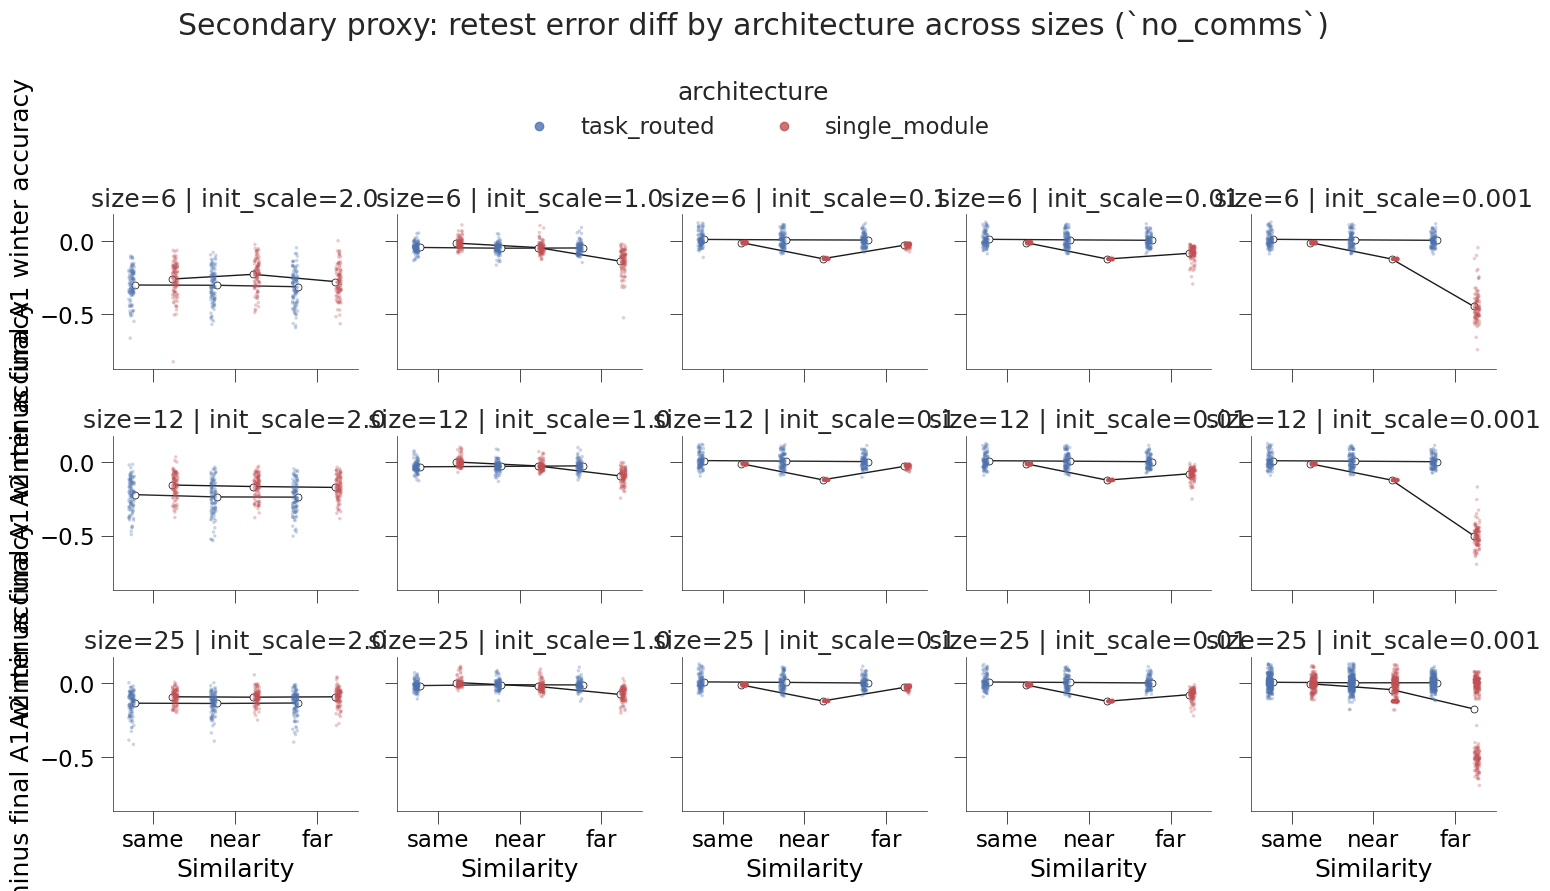

/tmp/ipykernel_1127332/474350701.py:237: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


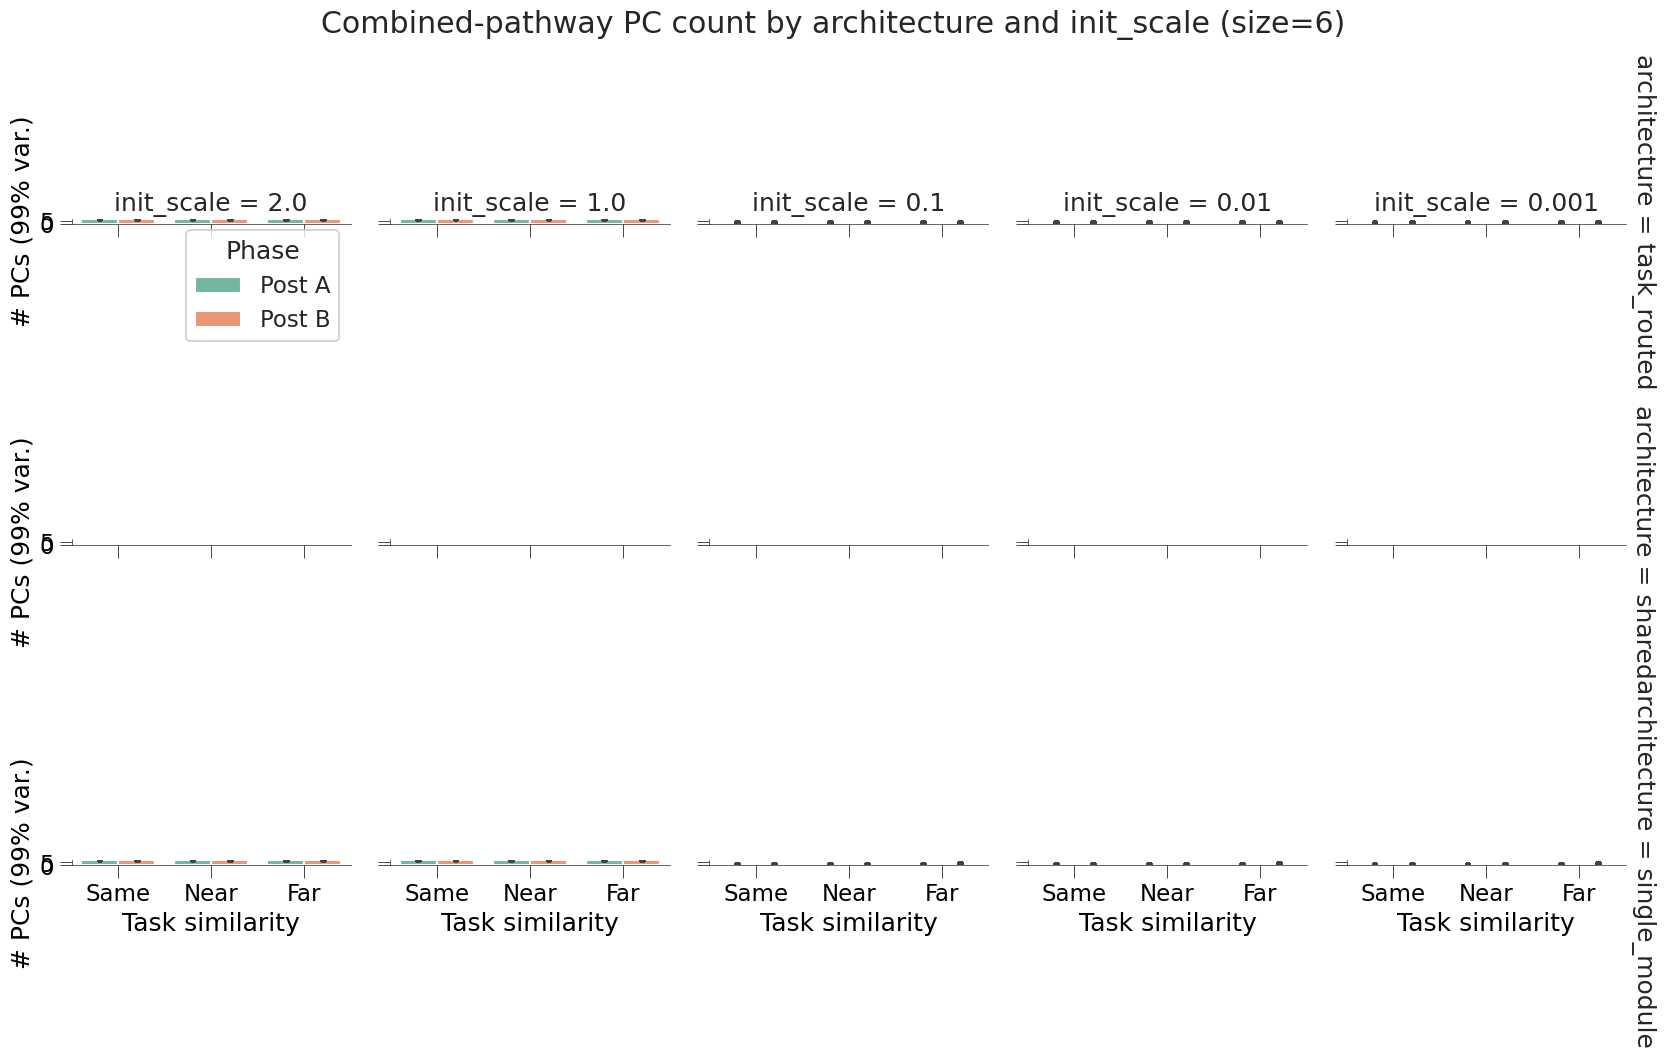

/tmp/ipykernel_1127332/474350701.py:237: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


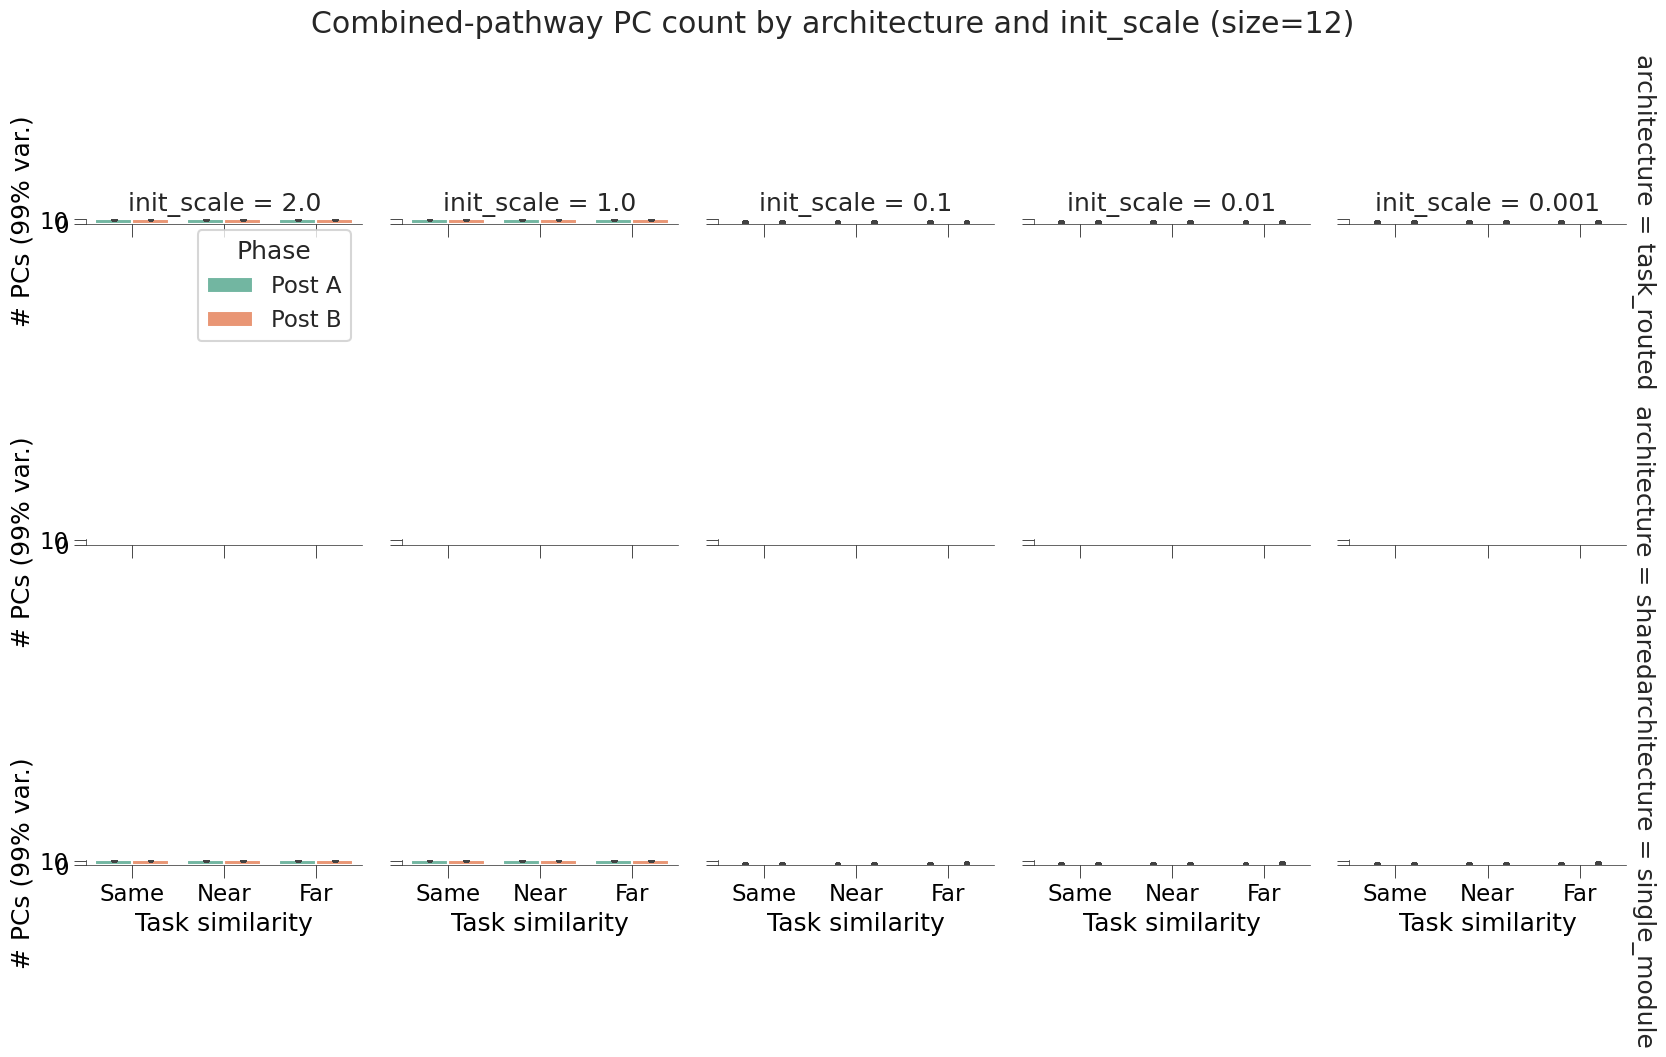

/tmp/ipykernel_1127332/474350701.py:237: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


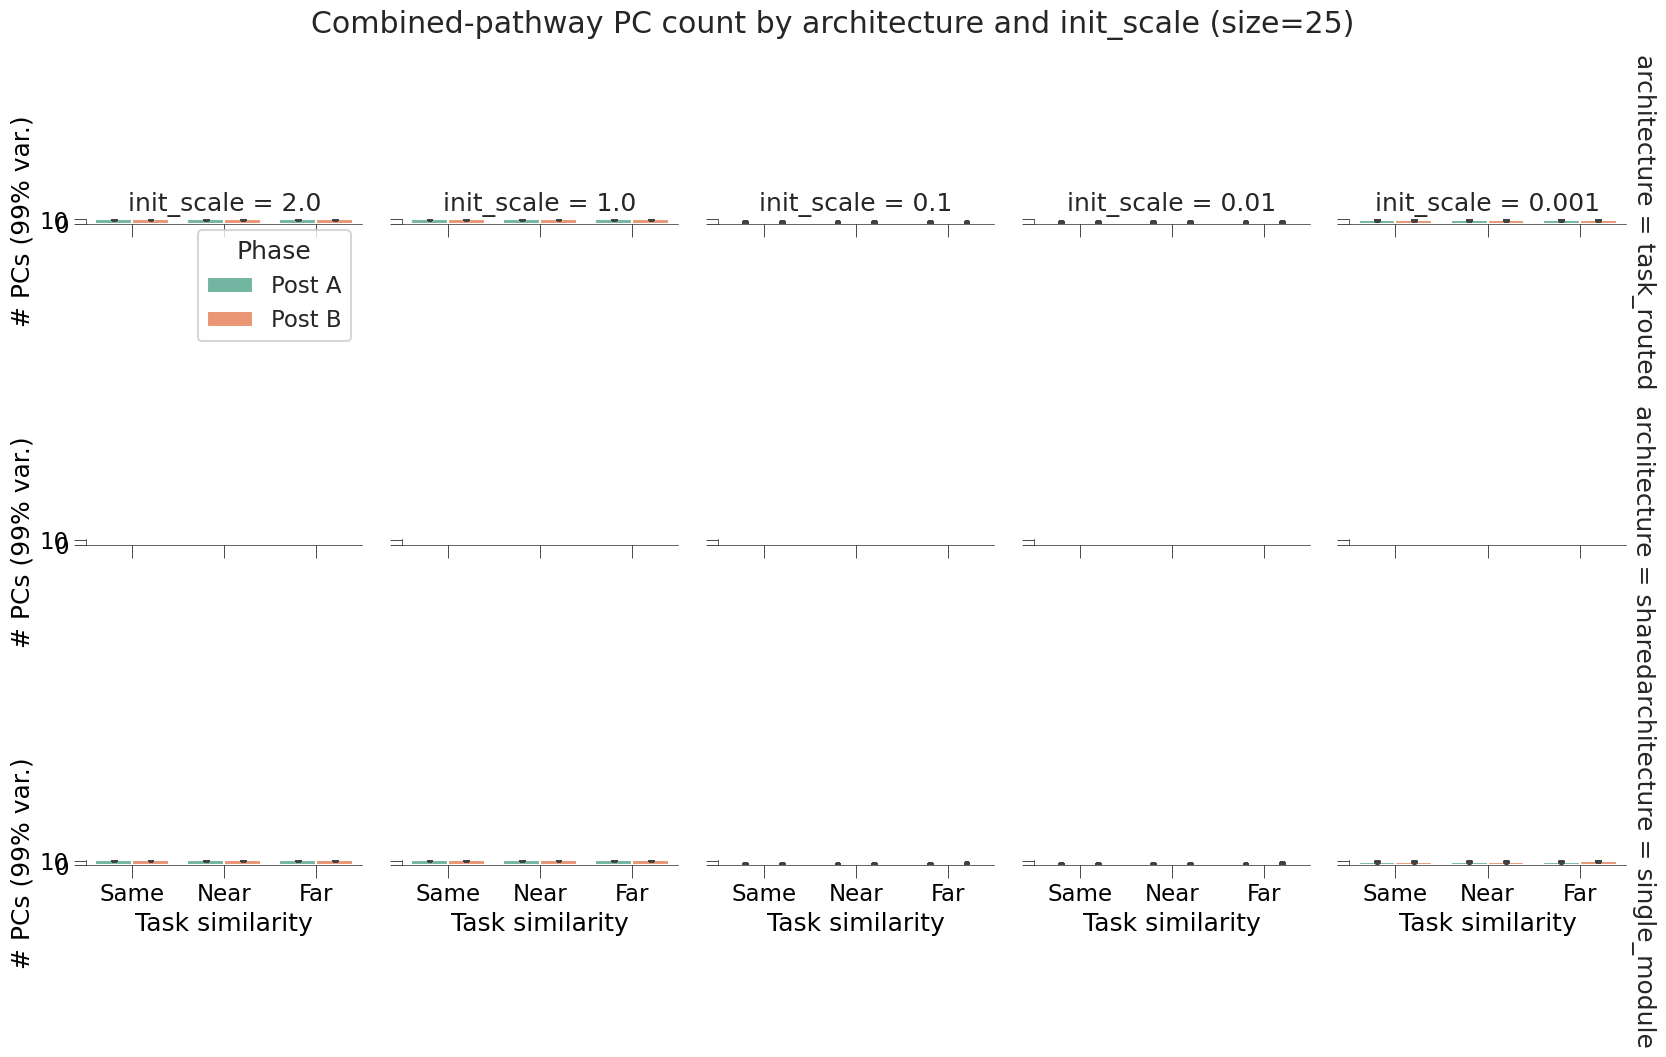

In [20]:
sns.set_theme(style="ticks", context="talk")


def _style_holton_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(colors="black", width=0.5)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.grid(False)


def _facet_plot(metric_df, value_col, title, y_label, *, condition_order):
    if metric_df is None or metric_df.empty:
        print(f"No rows for {title}.")
        return
    init_order_desc = [2.0, 1.0, 0.1, 0.01, 0.001]
    plot_df = metric_df.copy()
    plot_df = plot_df[
        plot_df["condition"].isin(condition_order)
        & plot_df["init_scale"].astype(float).isin(init_order_desc)
    ].copy()
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=condition_order, ordered=True)
    plot_df["architecture_group"] = pd.Categorical(plot_df["architecture_group"], categories=ROUTING_ORDER, ordered=True)
    plot_df["size"] = pd.Categorical(plot_df["size"], categories=SIZE_ORDER, ordered=True)
    plot_df["init_scale"] = pd.Categorical(plot_df["init_scale"].astype(float), categories=init_order_desc, ordered=True)

    g = sns.catplot(
        data=plot_df,
        x="condition",
        y=value_col,
        hue="architecture_group",
        col="init_scale",
        row="size",
        kind="strip",
        dodge=True,
        jitter=True,
        order=condition_order,
        hue_order=ROUTING_ORDER,
        col_order=init_order_desc,
        palette=ROUTING_PALETTE,
        size=2.5,
        linewidth=0,
        alpha=0.3,
        height=2.8,
        aspect=1.1,
        legend=False,
    )

    for ax_key, ax in g.axes_dict.items():
        if isinstance(ax_key, tuple):
            row_size, init_scale = ax_key
        else:
            row_size, init_scale = None, ax_key
        ax_df = plot_df.copy()
        if row_size is not None:
            ax_df = ax_df[ax_df["size"] == row_size]
        ax_df = ax_df[np.isclose(ax_df["init_scale"], float(init_scale))]
        if ax_df.empty:
            _style_holton_axes(ax)
            continue
        sns.pointplot(
            data=ax_df,
            x="condition",
            y=value_col,
            hue="architecture_group",
            order=condition_order,
            hue_order=ROUTING_ORDER,
            dodge=0.45,
            palette="dark:k",
            markers="",
            errorbar="se",
            linestyles="-",
            linewidth=1,
            ax=ax,
            legend=False,
        )
        sns.pointplot(
            data=ax_df,
            x="condition",
            y=value_col,
            hue="architecture_group",
            order=condition_order,
            hue_order=ROUTING_ORDER,
            dodge=0.45,
            palette=["k"] * len(ROUTING_ORDER),
            errorbar=None,
            markers="o",
            linestyles="",
            markersize=5,
            linewidth=0.75,
            ax=ax,
            legend=False,
            markerfacecolor="white",
            markeredgecolor="k",
        )
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        _style_holton_axes(ax)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor=ROUTING_PALETTE[label], markeredgecolor=ROUTING_PALETTE[label], alpha=0.8, label=label)
        for label in ROUTING_ORDER
        if label in plot_df["architecture_group"].astype(str).unique()
    ]
    if handles:
        g.fig.legend(
            handles=handles,
            labels=[h.get_label() for h in handles],
            title="architecture",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.01),
            ncol=len(handles),
            frameon=False,
        )
    g.set_axis_labels("Similarity", y_label)
    g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle(title, y=1.07)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


_facet_plot(
    transfer_df,
    "transfer_error_diff",
    "Paper-faithful transfer by architecture across sizes (`no_comms`)",
    "Transfer error diff",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot(
    interference_df,
    "interference",
    "Paper-faithful retest interference by architecture across sizes (`no_comms`)",
    "Retest interference\n$p$(Rule B)",
    condition_order=INTERFERENCE_ORDER,
)

_facet_plot(
    angles_df,
    "principal_angle_between",
    "A-B principal angles by architecture across sizes (`no_comms`)",
    "Principal angle (deg)",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot(
    generalisation_df,
    "generalisation_paper_faithful",
    "Paper-faithful generalisation by architecture across sizes (`no_comms`)",
    "Generalisation accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot(
    generalisation_df,
    "generalisation_holton_ann_style",
    "Holton ANN-style generalisation by architecture across sizes (`no_comms`)",
    "Generalisation accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot(
    secondary_ann_df,
    "summer_accuracy_taskA_scoped",
    "Task-A scoped summer accuracy by architecture across sizes (`no_comms`)",
    "Summer accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot(
    secondary_ann_df,
    "retest_error_diff",
    "Secondary proxy: retest error diff by architecture across sizes (`no_comms`)",
    "A2 minus final A1 winter accuracy",
    condition_order=SIMILARITY_ORDER,
)

if not representation_df.empty and "n_pcs_99" in representation_df.columns:
    rep_plot = representation_df[
        (representation_df["pathway"] == "combined")
        & (representation_df["phase"].isin(["post_A", "post_B"]))
        & (representation_df["condition"].isin(SIMILARITY_ORDER))
    ].copy()
    rep_plot["condition"] = pd.Categorical(rep_plot["condition"], categories=SIMILARITY_ORDER, ordered=True)
    rep_plot["phase"] = pd.Categorical(rep_plot["phase"], categories=["post_A", "post_B"], ordered=True)
    rep_plot["architecture_group"] = pd.Categorical(rep_plot["architecture_group"], categories=ROUTING_ORDER, ordered=True)
    rep_plot["size"] = pd.Categorical(rep_plot["size"], categories=SIZE_ORDER, ordered=True)
    rep_plot["init_scale"] = rep_plot["init_scale"].astype(float)

    phase_labels = {"post_A": "Post A", "post_B": "Post B"}
    cond_labels = {"same": "Same", "near": "Near", "far": "Far"}
    init_order_desc = [2.0, 1.0, 0.1, 0.01, 0.001]

    for size in SIZE_ORDER:
        sub = rep_plot[rep_plot["size"] == size].copy()
        if sub.empty:
            continue

        sub["phase_plot"] = sub["phase"].map(phase_labels)
        sub["condition_plot"] = sub["condition"].map(cond_labels)
        sub["init_scale"] = pd.Categorical(sub["init_scale"], categories=init_order_desc, ordered=True)

        g = sns.catplot(
            data=sub,
            x="condition_plot",
            y="n_pcs_99",
            hue="phase_plot",
            col="init_scale",
            row="architecture_group",
            kind="bar",
            order=["Same", "Near", "Far"],
            hue_order=["Post A", "Post B"],
            col_order=init_order_desc,
            row_order=ROUTING_ORDER,
            palette="Set2",
            height=3.4,
            aspect=1.0,
            legend_out=False,
            margin_titles=True,
            errorbar="se",
            capsize=0.04,
        )
        g.set_axis_labels("Task similarity", "# PCs (99% var.)")
        g.set_titles(row_template="architecture = {row_name}", col_template="init_scale = {col_name}")
        if g._legend is not None:
            g._legend.set_title("Phase")
        for ax in g.axes.flat:
            _style_holton_axes(ax)
        g.fig.suptitle(
            f"Combined-pathway PC count by architecture and init_scale (size={size})",
            y=1.03,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()
else:
    print("No representation histogram available.")


## Alternative summary views: metric vs. init_scale by task similarity

This final section re-expresses each main metric as a function of `init_scale`, with separate plots for each task-similarity condition. Each plot keeps the architecture comparison visible and uses the same descending init-scale order: `2`, `1`, `0.1`, `0.01`, `0.001`.


## Verification checklist

- Transfer is computed from raw `sim_*.npz` files as **first 6 B winter minus last 6 A1 winter**.
- Interference is loaded from von Mises fit CSVs as **`1 - A_weight_A2`**.
- Interference is restricted to **`near`** and **`far`**.
- Coverage diagnostics remain visible so missing size-6 single-module runs are explicit before figure interpretation.
- Plot styling follows the blueprint’s Holton-style summary plots: participant stripplot, black `SE` bars, white mean markers, minimal axes, explicit architecture legend.


## Principal angles (supplementary)

Two additional views: (1) task-routed vs single-module only with loss-curve colors and init columns high→low; (2) all init scales overlaid with a purple→yellow gradient (mean ± SEM per init).


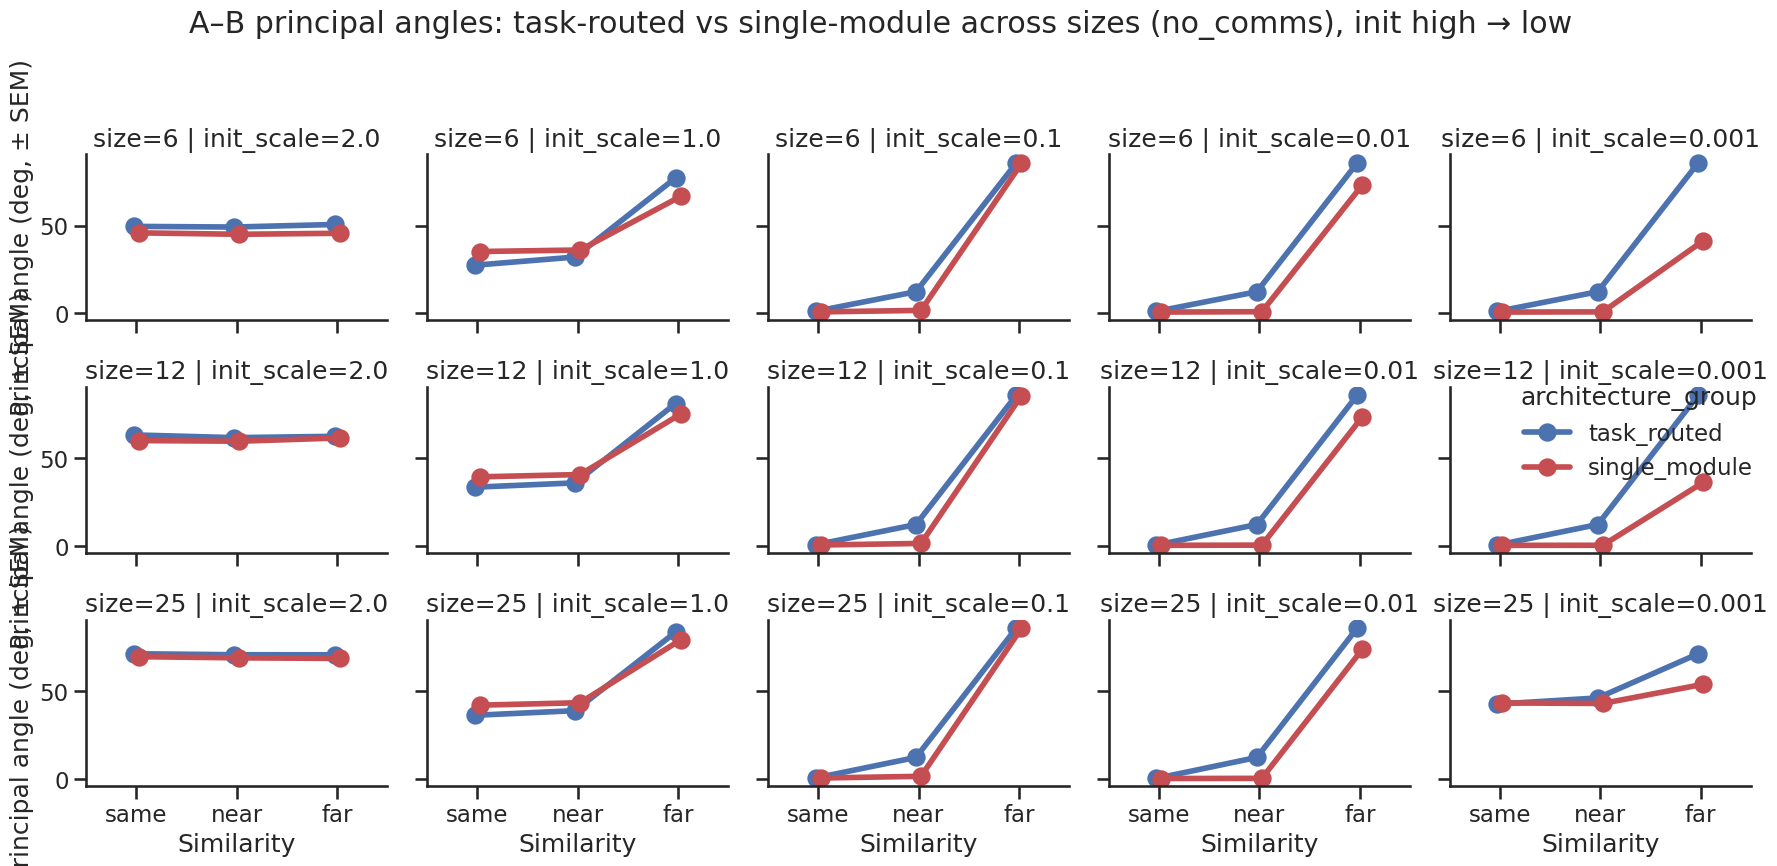

In [21]:
# Figure 1: task_routed vs single_module; init high → low; loss-notebook colors
TWO_ARCH_PALETTE = {"task_routed": "#4C72B0", "single_module": "#C44E52"}
TWO_ARCH_ORDER = ["task_routed", "single_module"]
init_order_desc = [2.0, 1.0, 0.1, 0.01, 0.001]

if angles_df is None or angles_df.empty:
    print("No angles_df for two-architecture principal angles plot.")
else:
    plot_df = angles_df[angles_df["architecture_group"].isin(TWO_ARCH_ORDER)].copy()
    if plot_df.empty:
        print("No rows for two-architecture principal angles plot.")
    else:
        plot_df["init_scale"] = plot_df["init_scale"].astype(float)
        col_order = [s for s in init_order_desc if plot_df["init_scale"].apply(lambda x: np.isclose(x, s)).any()]
        plot_df["size"] = pd.Categorical(plot_df["size"], categories=SIZE_ORDER, ordered=True)
        g = sns.catplot(
            data=plot_df,
            x="condition",
            y="principal_angle_between",
            hue="architecture_group",
            col="init_scale",
            row="size",
            col_order=col_order,
            row_order=SIZE_ORDER,
            kind="point",
            dodge=True,
            order=SIMILARITY_ORDER,
            hue_order=TWO_ARCH_ORDER,
            palette=TWO_ARCH_PALETTE,
            height=2.8,
            aspect=1.1,
            errorbar="se",
            capsize=0.08,
        )
        g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
        g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
        g.fig.suptitle(
            "A–B principal angles: task-routed vs single-module across sizes (no_comms), init high → low",
            y=1.04,
        )
        plt.tight_layout()
        plt.show()


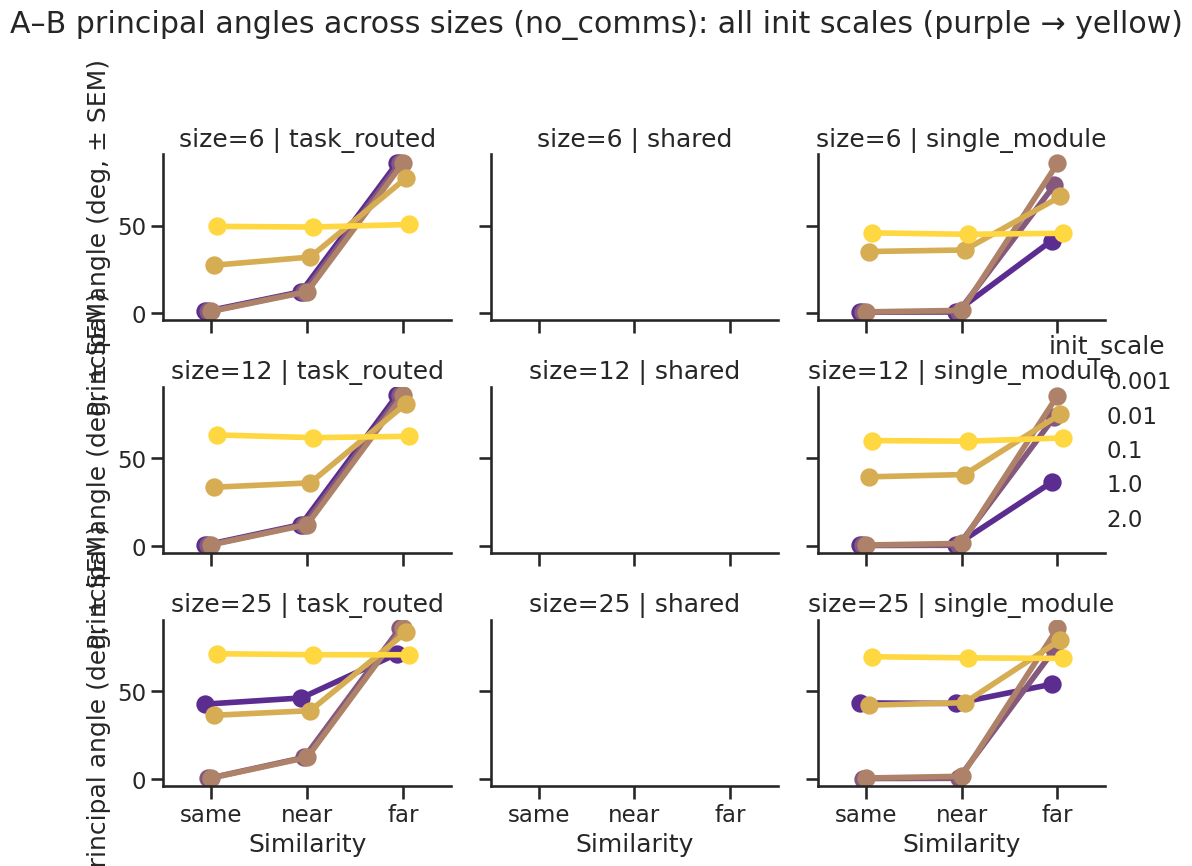

In [22]:
# Figure 2: all architectures × sizes; hue = init_scale (purple → yellow)
import matplotlib.colors as mcolors

_py_cmap = mcolors.LinearSegmentedColormap.from_list(
    "init_purple_yellow", ["#5c2d91", "#ffd740"], N=256
)
_paper_inits = [0.001, 0.01, 0.1, 1.0, 2.0]
INIT_COLORS_GRAD = {
    float(s): _py_cmap(i / max(1, len(_paper_inits) - 1))
    for i, s in enumerate(_paper_inits)
}

if angles_df is None or angles_df.empty:
    print("No angles_df for gradient principal angles plot.")
else:
    plot_df = angles_df.copy()
    plot_df["init_scale"] = plot_df["init_scale"].astype(float)
    plot_df["size"] = pd.Categorical(plot_df["size"], categories=SIZE_ORDER, ordered=True)
    plot_df["architecture_group"] = pd.Categorical(
        plot_df["architecture_group"], categories=ROUTING_ORDER, ordered=True
    )
    hue_order = [
        s for s in _paper_inits
        if plot_df["init_scale"].apply(lambda x: np.isclose(x, s)).any()
    ]
    palette = [INIT_COLORS_GRAD[s] for s in hue_order]
    g = sns.catplot(
        data=plot_df,
        x="condition",
        y="principal_angle_between",
        hue="init_scale",
        row="size",
        col="architecture_group",
        row_order=SIZE_ORDER,
        col_order=ROUTING_ORDER,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=hue_order,
        palette=palette,
        height=2.8,
        aspect=1.1,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
    g.set_titles(row_template="size={row_name}", col_template="{col_name}")
    g.fig.suptitle(
        "A–B principal angles across sizes (no_comms): all init scales (purple → yellow)",
        y=1.04,
    )
    plt.tight_layout()
    plt.show()


## Pointplot-only variants (mean ± SEM)

Same faceting and filters as the main quantitative figures above (`init_scale` columns left→right `2` … `0.001`, `size` rows), but **only** Seaborn `pointplot`-style summaries (no stripplot underlay). Use these for a compact read when participant clouds are not needed.


/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


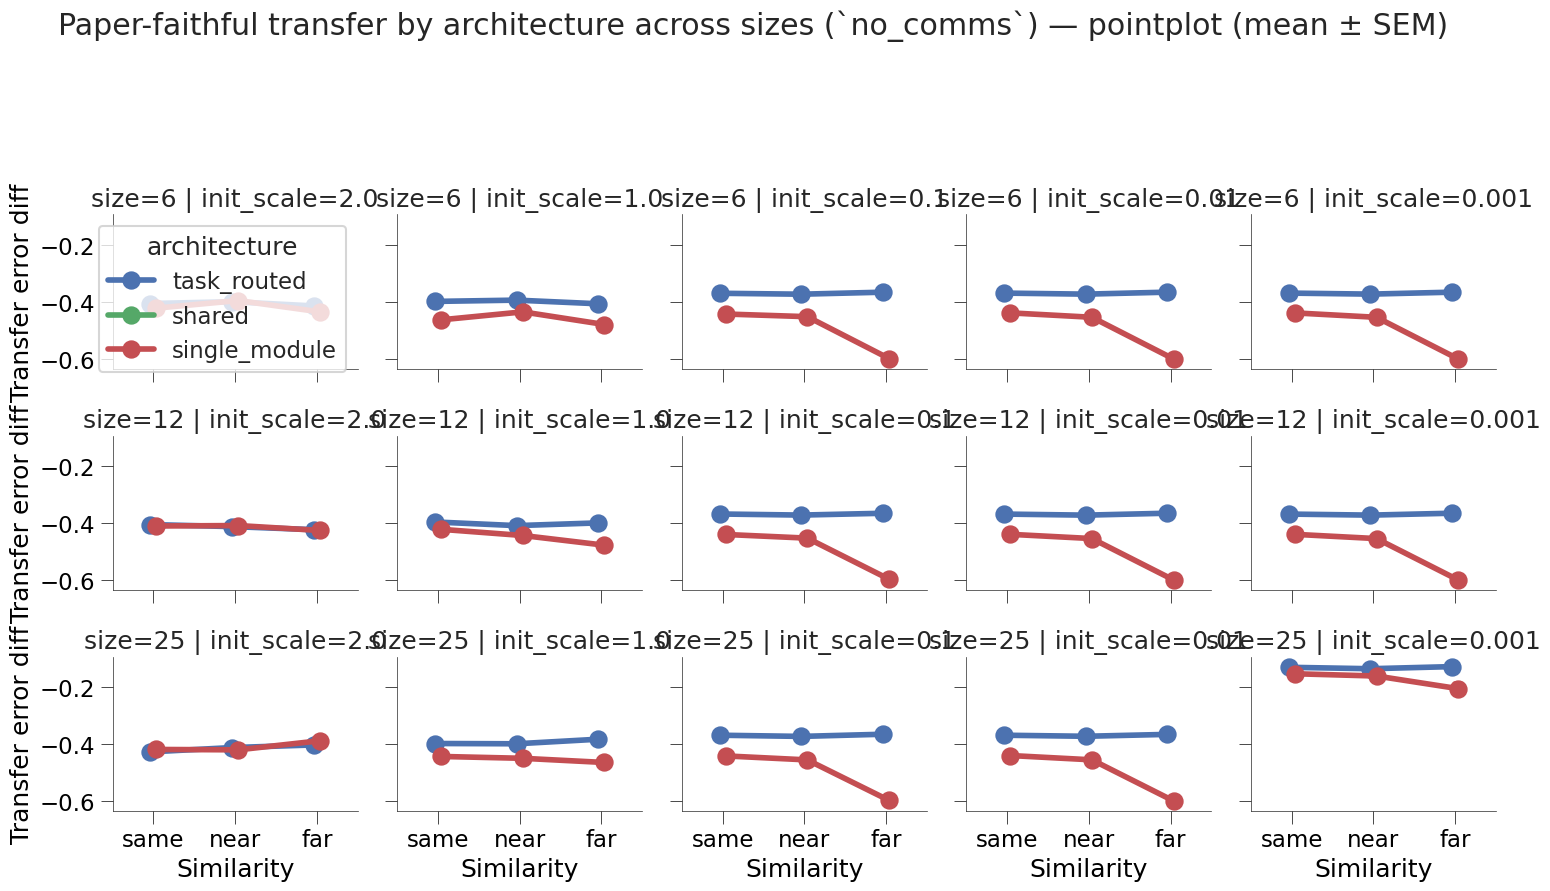

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


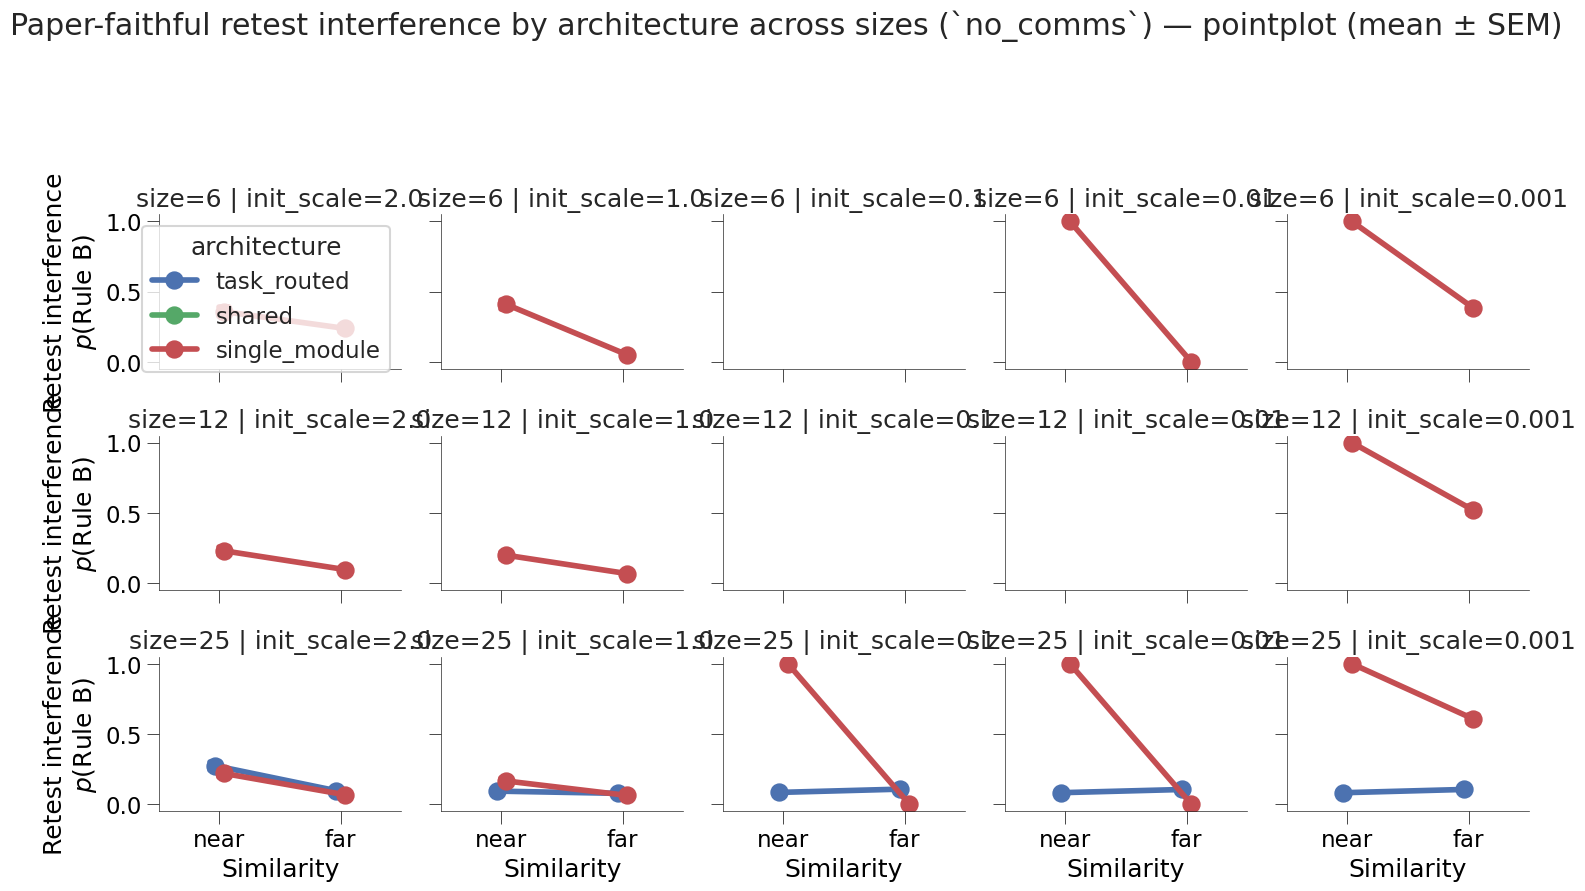

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


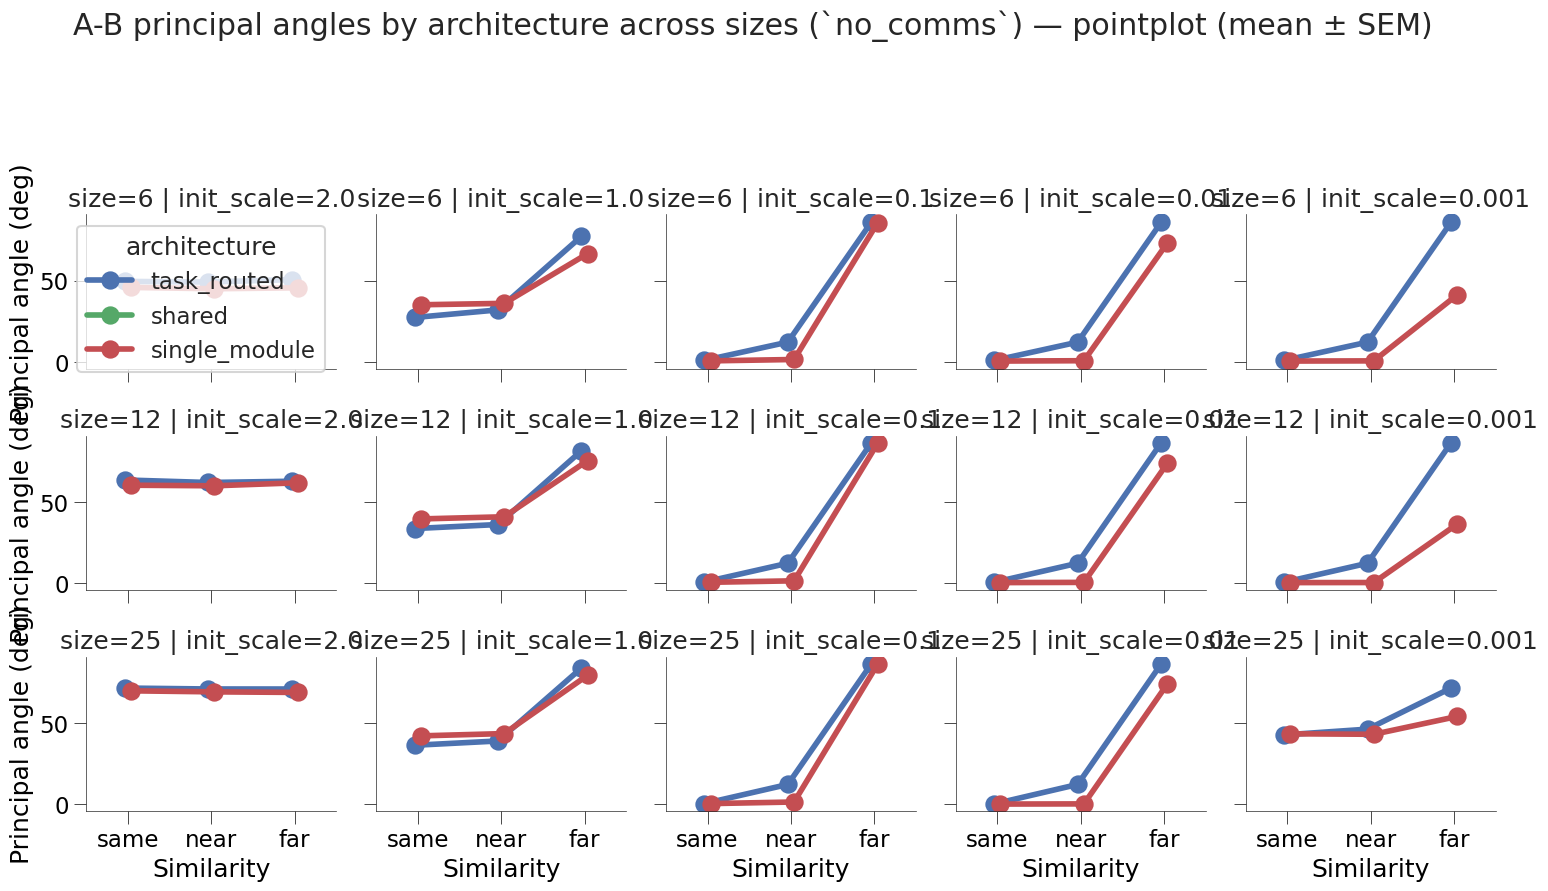

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


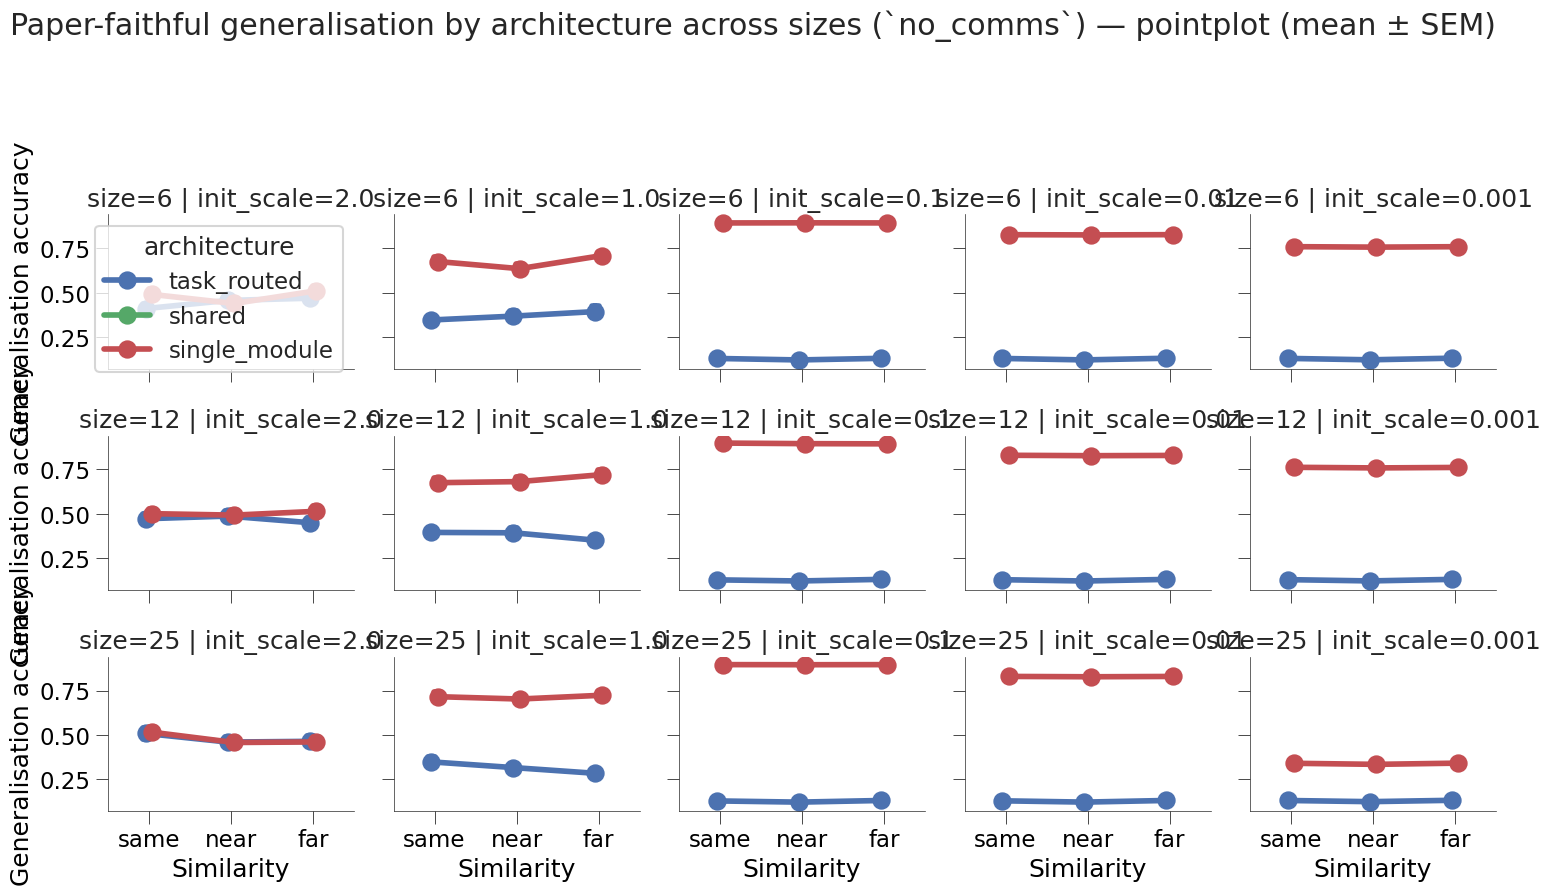

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


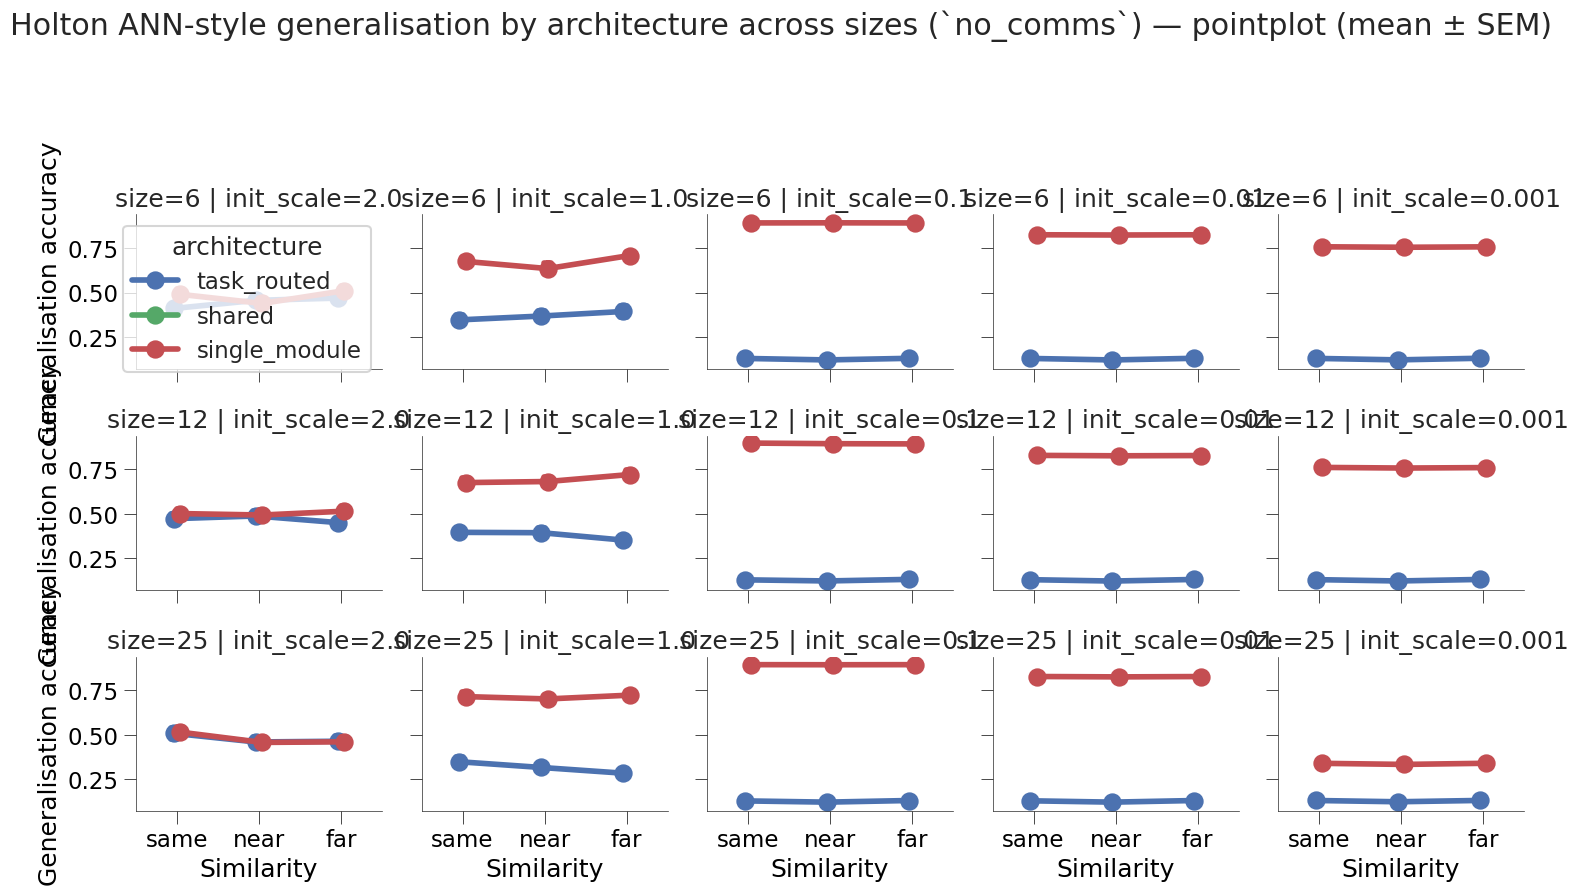

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


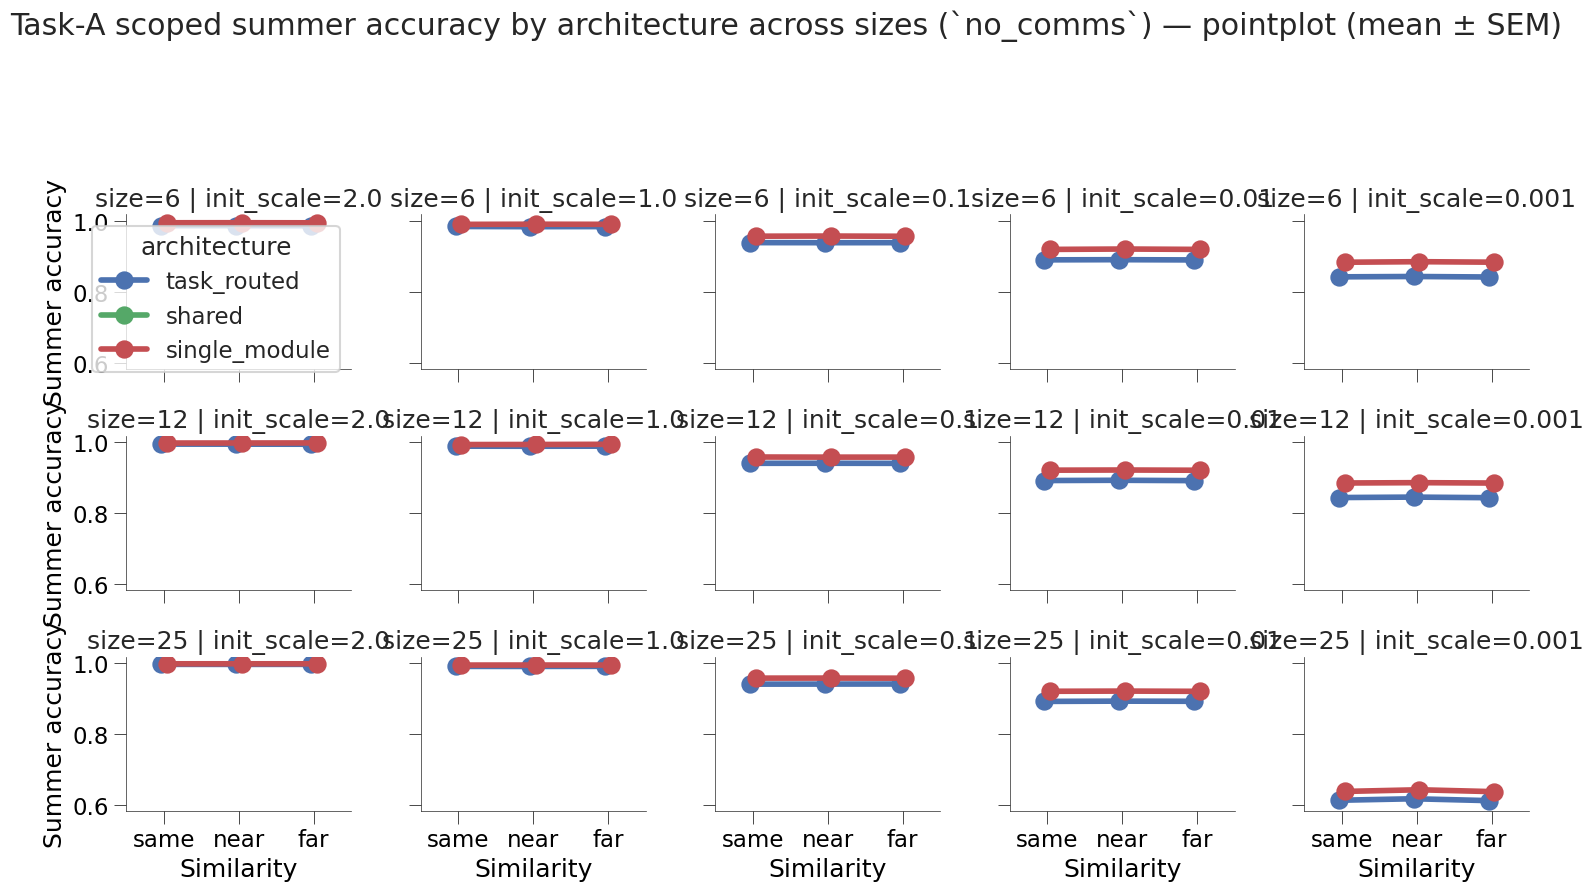

/tmp/ipykernel_1127332/610895916.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


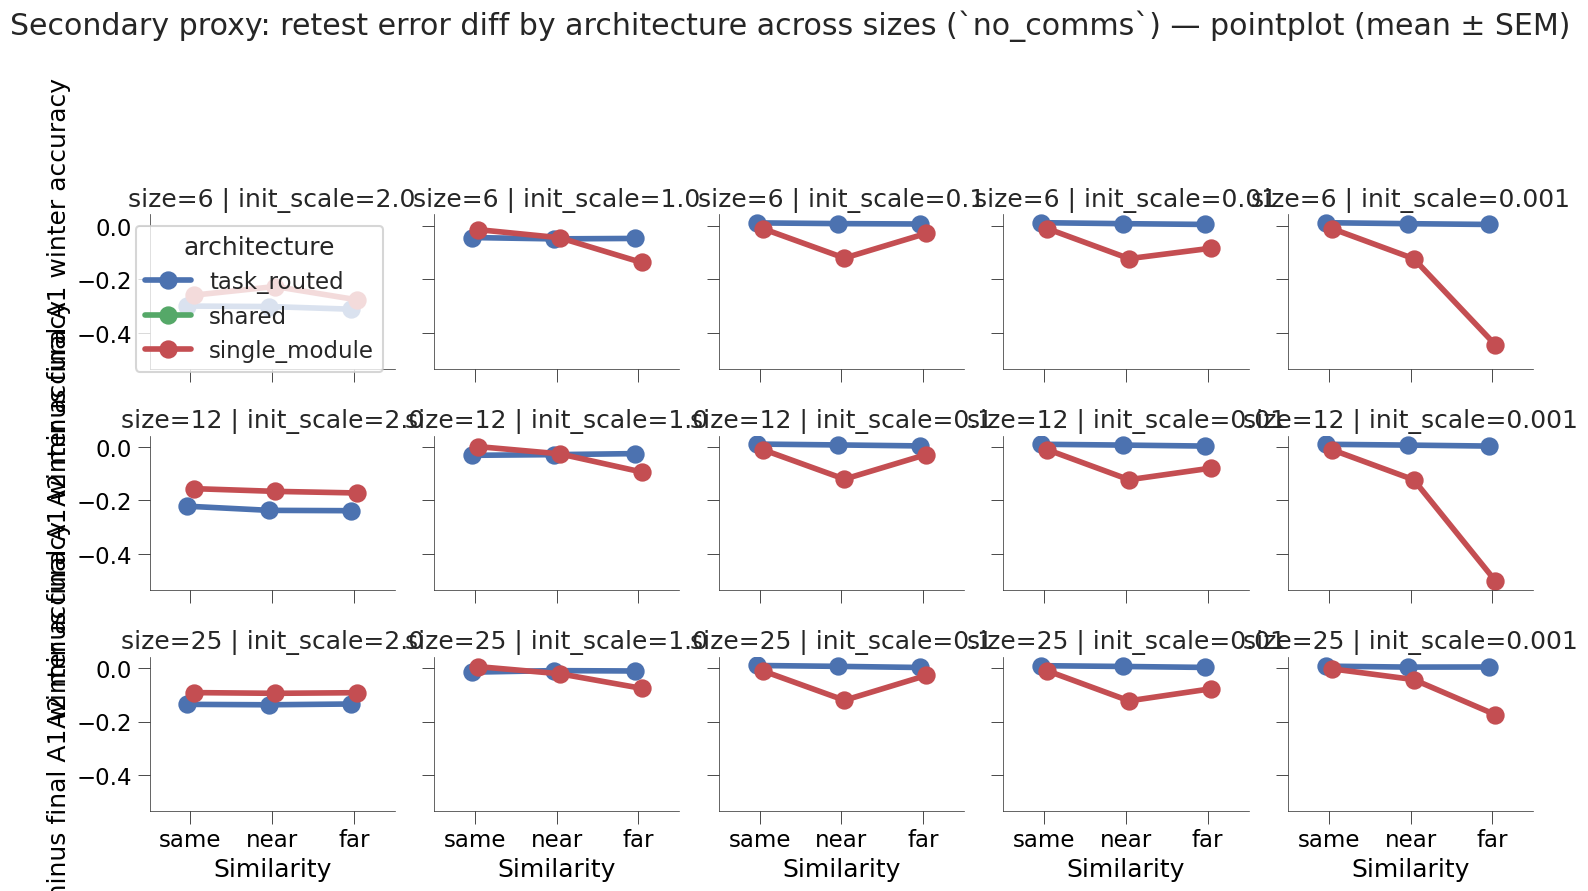

/tmp/ipykernel_1127332/610895916.py:129: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(
/tmp/ipykernel_1127332/610895916.py:161: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


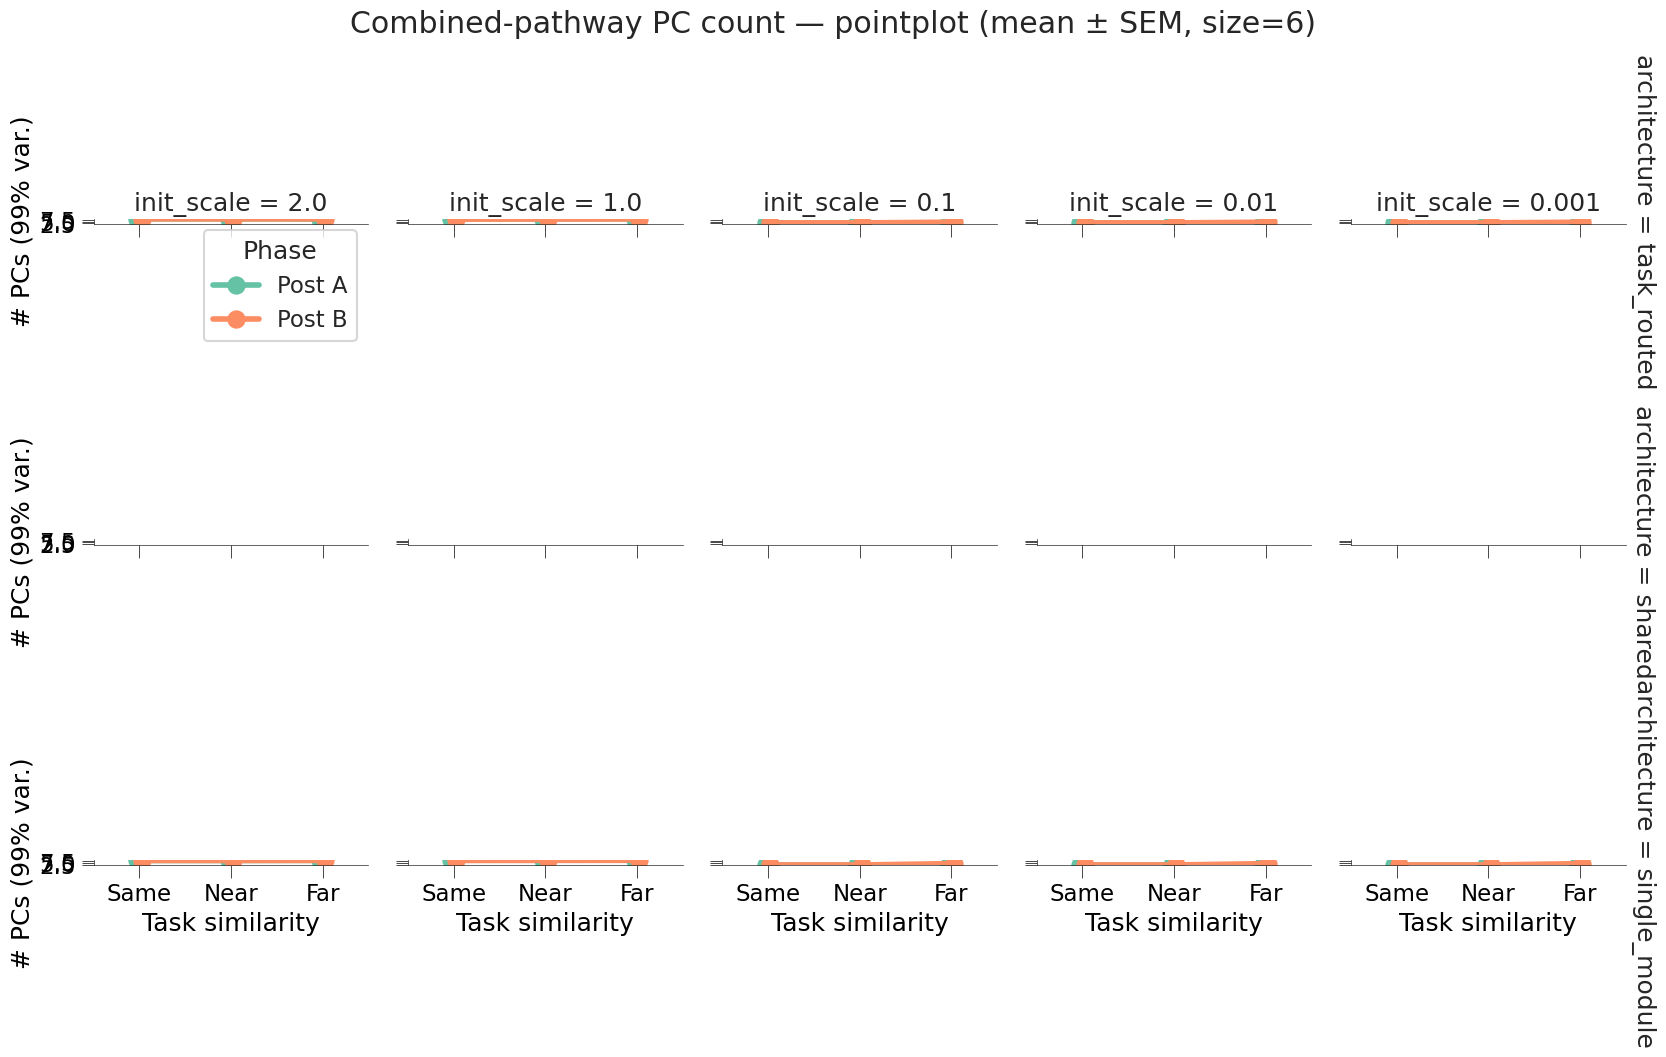

/tmp/ipykernel_1127332/610895916.py:129: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(
/tmp/ipykernel_1127332/610895916.py:161: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


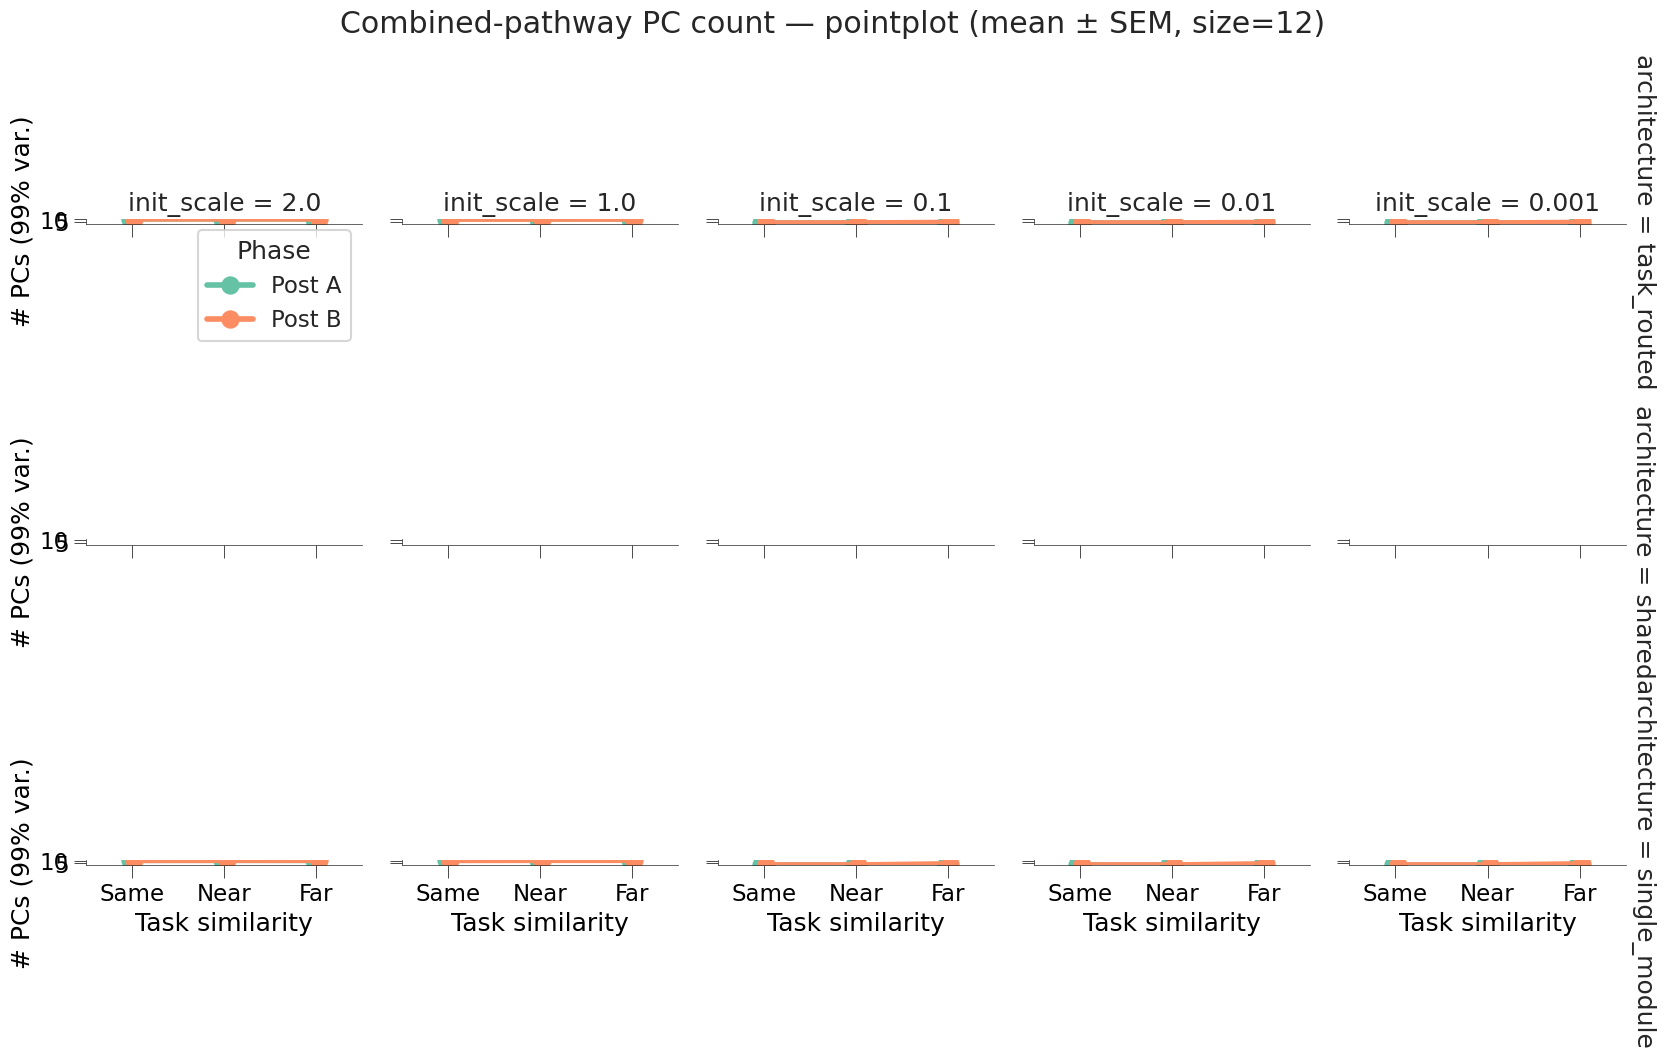

/tmp/ipykernel_1127332/610895916.py:129: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(
/tmp/ipykernel_1127332/610895916.py:161: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


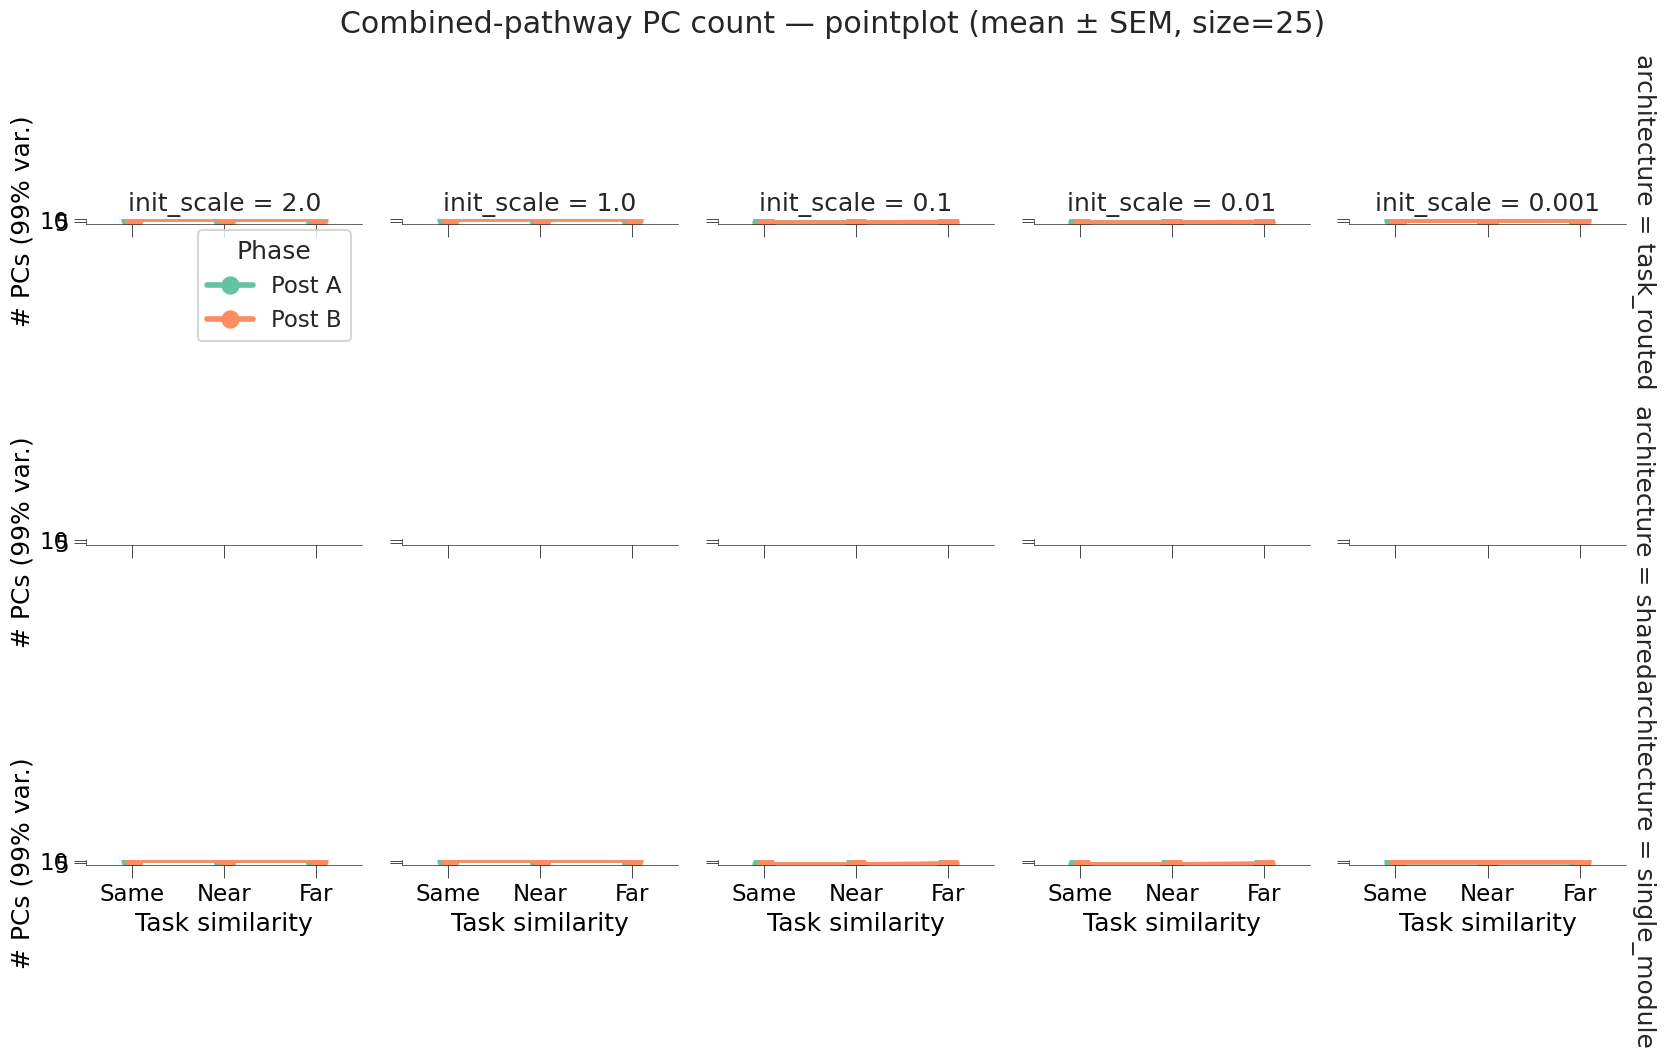

In [23]:
def _facet_plot_point_only(metric_df, value_col, title, y_label, *, condition_order):
    if metric_df is None or metric_df.empty:
        print(f"No rows for {title}.")
        return
    init_order_desc = [2.0, 1.0, 0.1, 0.01, 0.001]
    plot_df = metric_df.copy()
    plot_df = plot_df[
        plot_df["condition"].isin(condition_order)
        & plot_df["init_scale"].astype(float).isin(init_order_desc)
    ].copy()
    if plot_df.empty:
        print(f"No rows for {title} (after init_scale filter).")
        return
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=condition_order, ordered=True)
    plot_df["architecture_group"] = pd.Categorical(plot_df["architecture_group"], categories=ROUTING_ORDER, ordered=True)
    plot_df["size"] = pd.Categorical(plot_df["size"], categories=SIZE_ORDER, ordered=True)
    plot_df["init_scale"] = pd.Categorical(plot_df["init_scale"].astype(float), categories=init_order_desc, ordered=True)

    g = sns.catplot(
        data=plot_df,
        x="condition",
        y=value_col,
        hue="architecture_group",
        col="init_scale",
        row="size",
        kind="point",
        dodge=True,
        join=True,
        order=condition_order,
        hue_order=ROUTING_ORDER,
        col_order=init_order_desc,
        palette=ROUTING_PALETTE,
        height=2.8,
        aspect=1.1,
        errorbar="se",
        capsize=0.08,
        legend_out=False,
    )
    for ax in g.axes.flat:
        _style_holton_axes(ax)
    g.set_axis_labels("Similarity", y_label)
    g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
    if g._legend is not None:
        g._legend.set_title("architecture")
    g.fig.suptitle(f"{title} — pointplot (mean ± SEM)", y=1.07)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


_facet_plot_point_only(
    transfer_df,
    "transfer_error_diff",
    "Paper-faithful transfer by architecture across sizes (`no_comms`)",
    "Transfer error diff",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot_point_only(
    interference_df,
    "interference",
    "Paper-faithful retest interference by architecture across sizes (`no_comms`)",
    "Retest interference\n$p$(Rule B)",
    condition_order=INTERFERENCE_ORDER,
)

_facet_plot_point_only(
    angles_df,
    "principal_angle_between",
    "A-B principal angles by architecture across sizes (`no_comms`)",
    "Principal angle (deg)",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot_point_only(
    generalisation_df,
    "generalisation_paper_faithful",
    "Paper-faithful generalisation by architecture across sizes (`no_comms`)",
    "Generalisation accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot_point_only(
    generalisation_df,
    "generalisation_holton_ann_style",
    "Holton ANN-style generalisation by architecture across sizes (`no_comms`)",
    "Generalisation accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot_point_only(
    secondary_ann_df,
    "summer_accuracy_taskA_scoped",
    "Task-A scoped summer accuracy by architecture across sizes (`no_comms`)",
    "Summer accuracy",
    condition_order=SIMILARITY_ORDER,
)

_facet_plot_point_only(
    secondary_ann_df,
    "retest_error_diff",
    "Secondary proxy: retest error diff by architecture across sizes (`no_comms`)",
    "A2 minus final A1 winter accuracy",
    condition_order=SIMILARITY_ORDER,
)

if not representation_df.empty and "n_pcs_99" in representation_df.columns:
    rep_pt = representation_df[
        (representation_df["pathway"] == "combined")
        & (representation_df["phase"].isin(["post_A", "post_B"]))
        & (representation_df["condition"].isin(SIMILARITY_ORDER))
    ].copy()
    rep_pt["init_scale"] = rep_pt["init_scale"].astype(float)
    init_order_desc = [2.0, 1.0, 0.1, 0.01, 0.001]
    rep_pt = rep_pt[rep_pt["init_scale"].isin(init_order_desc)].copy()
    if not rep_pt.empty:
        phase_labels = {"post_A": "Post A", "post_B": "Post B"}
        cond_labels = {"same": "Same", "near": "Near", "far": "Far"}
        rep_pt["phase_plot"] = rep_pt["phase"].map(phase_labels)
        rep_pt["condition_plot"] = rep_pt["condition"].map(cond_labels)
        rep_pt["condition"] = pd.Categorical(rep_pt["condition"], categories=SIMILARITY_ORDER, ordered=True)
        rep_pt["architecture_group"] = pd.Categorical(rep_pt["architecture_group"], categories=ROUTING_ORDER, ordered=True)
        rep_pt["size"] = pd.Categorical(rep_pt["size"], categories=SIZE_ORDER, ordered=True)
        rep_pt["init_scale"] = pd.Categorical(rep_pt["init_scale"], categories=init_order_desc, ordered=True)

        for size in SIZE_ORDER:
            sub = rep_pt[rep_pt["size"] == size].copy()
            if sub.empty:
                continue
            g = sns.catplot(
                data=sub,
                x="condition_plot",
                y="n_pcs_99",
                hue="phase_plot",
                col="init_scale",
                row="architecture_group",
                kind="point",
                dodge=True,
                join=True,
                order=["Same", "Near", "Far"],
                hue_order=["Post A", "Post B"],
                col_order=init_order_desc,
                row_order=ROUTING_ORDER,
                palette="Set2",
                height=3.4,
                aspect=1.0,
                errorbar="se",
                capsize=0.08,
                legend_out=False,
                margin_titles=True,
            )
            g.set_axis_labels("Task similarity", "# PCs (99% var.)")
            g.set_titles(row_template="architecture = {row_name}", col_template="init_scale = {col_name}")
            if g._legend is not None:
                g._legend.set_title("Phase")
            for ax in g.axes.flat:
                _style_holton_axes(ax)
            g.fig.suptitle(
                f"Combined-pathway PC count — pointplot (mean ± SEM, size={size})",
                y=1.03,
            )
            plt.tight_layout(rect=[0, 0, 1, 0.98])
            plt.show()
    else:
        print("No PC-count rows after init_scale filter for pointplot.")
else:
    print("No representation data for PC-count pointplot.")
